In [ ]:
# !pip install plyer
# !pip install transformers
# !pip install --upgrade openai




# Before Main Functions

## Imports

In [ ]:
import traceback, os, pandas as pd, json, seaborn as sns, matplotlib.pyplot as plt, numpy as np, logging, re, sys
from openai import OpenAI
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import datetime
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, confusion_matrix,
    classification_report, top_k_accuracy_score, roc_auc_score, auc, roc_curve)
from xgboost import XGBClassifier
from sentence_transformers import SentenceTransformer
from transformers import AutoTokenizer
from collections import defaultdict
import itertools, html
from sklearn.metrics.pairwise import cosine_similarity

from google.colab import userdata
os.environ['OPENAI_API_KEY'] = userdata.get('OPENAI_API_KEY')

##Connect trait synonym to trait name

In [ ]:
def load_trait(personality_trait: str):
    traits = {
        'o':'openness to experiences',
        'c': 'conscientiousness',
        'e': 'extraversion',
        'a': 'aggreeableness',
        'n': 'neuroticism'}
    return traits[personality_trait]

In [ ]:
def load_descr(personality_trait: str):
    descriptions = {
        'n' : 'Tendency to experience negative emotions such as anxiety, depression, and irritability.',
        'e' : 'Tendency to be sociable, energetic, and assertive.',
        'a' : 'Tendency to be cooperative, altruistic, and empathetic.',
        'c' : 'Tendency to be organized, disciplined, and responsible.',
        'o' : 'Tendency to be curious, imaginative, and open to new ideas'
    }
    return descriptions[personality_trait]

## Prompts

### Prompts for creating low and high levels' rules based on original assessments

#### prompt_create_rules_low_level

In [ ]:
def prompt_create_rules_low_level(personality_trait, assessments):
    system_content = f'''You are helping design structured, behavior-based classification rules for identifying the Big Five personality trait level {load_trait(personality_trait)} of a writer based on text (e.g., social media posts).

You will receive multiple psychologist-written assessments that describe behaviors correlated with a low {load_trait(personality_trait)} level.

From those assessments, extract behavioral patterns and write clear, structured classification rules.

⚠️ Another agent will later classify posts using only the rules you generate. Your output must be self-contained, specific, and consistent in structure. Rules must generalize to a variety of writing styles and contexts.

🔸 Your Task:

Read and analyze the behavioral assessments.

Identify distinct, observable behavioral patterns linked to low {load_trait(personality_trait)}.

Generate a rule only if the behavior appears in at least two different assessments.

Output each rule as a JSON object in a list.

Ensure all fields are filled, follow strict structure, and avoid vague/general language.

🔹 Output Format (JSON):

[
{{
"rule_name": "Short descriptive name summarizing the behavior (e.g., 'Avoidance of Group Plans')",
"level": "low",
"behavior_rule": "If the person expresses / describes / shows in their post [observable behavior / linguistic pattern], then {load_trait(personality_trait)} is likely low because [brief rationale linked to the behavior itself].",
"supporting_examples": [
"Quote 1 from assessments that shows this behavior clearly",
"Quote 2 from assessments with similar behavior",
"Optional: Quote 3 (if available)"
],
"edge_cases": [
"Situations where this behavior appears but does NOT reflect low {load_trait(personality_trait)} (e.g., mentions of social fatigue after a positive event)",
"Avoid false positives from sarcasm, obligation, or non-preference-based behaviors"
],

}}
...
]

---

🔸 Constraints

- Use **only** patterns clearly present in the provided assessments. No outside knowledge or generalizations.
- A rule should be included **only if** it is:
  - **Behaviorally specific**
  - **Distinct from other rules**
  - **Potentially useful for classifying unseen real-world posts**

- Rules should **match conservatively**: only if the behavioral signal is **clearly evident** and would likely be recognized by a human psychologist.
- Limit output to **3 to 6 rules** maximum.

🔸 Generalization & Strengthening Guidelines

If several quotes express the same behavioral tendency, merge them into one generalized rule.

Favor stylistic and content-level signals over fixed phrases.

Avoid rules that rely solely on absence (e.g., “does not mention people”).

Ensure every rule captures a clear behavior, not just a lack of high trait behavior.

Each rule must be univariate: represent only one behavioral signal.

Avoid interpreting emotional states unless explicitly stated in the language (e.g., “I hate crowds” is okay; “seems anxious” is not).

---
🚫 Rule Rejection Criteria

Do not include a rule if:

It relies on vague emotional descriptions without clear behavioral grounding (e.g., “shows excitement”, “seems to enjoy company”).

It could match a large portion of neutral or positive social posts regardless of trait (e.g., birthday or family messages).

It overlaps significantly with another rule without introducing a new behavioral signal.

It merely rephrases an existing rule or expresses the same idea using different emotional terms.

It is based on inferred psychological states or attitudes not clearly observable in the text.

It could match sarcastic, humorous, or context-driven behavior without indicating a true trait signal.

It lacks identifiable linguistic cues or is too abstract for a language model to apply reliably.

Instead, prefer rules that:

Are anchored in language-level behaviors or distinct verbal styles.

Can be reasonably verified using linguistic evidence from the text alone.

Would apply only when a meaningful behavioral signal is present, and not just because the post topic is social or emotional in nature.

🔸 Final Note

Your output must be valid JSON only, with no extra explanation or headings. These rules will be parsed and applied by another AI agent without context, so clarity, behavioral grounding, and minimal ambiguity are critical.
'''

    user_content = f'''
Below are psychologist-written assessments based on social media posts. Each assessment includes:

    - A trait rating (low or moderate)

    - A brief explanation justifying that rating

    ---

    Assessments:

    {assessments}
'''
    return system_content, user_content

#### prompt_create_rules_high_level

In [ ]:
def prompt_create_rules_high_level(personality_trait, assessments):
    system_content = f'''You are helping design structured, behavior-based classification rules for identifying the Big Five personality trait level {load_trait(personality_trait)} of a writer based on text (e.g., social media posts).

You will receive multiple psychologist-written assessments that describe behaviors correlated with a high {load_trait(personality_trait)} level.

From those assessments, extract behavioral patterns and write clear, structured classification rules.

⚠️ Another agent will later classify posts using only the rules you generate. Your output must be self-contained, specific, and consistent in structure. Rules must generalize to a variety of writing styles and contexts.

🔸 Your Task:

Read and analyze the behavioral assessments.

Identify distinct, observable behavioral patterns linked to high {load_trait(personality_trait)}.

Generate a rule only if the behavior appears in at least two different assessments.

Output each rule as a JSON object in a list.

Ensure all fields are filled, follow strict structure, and avoid vague/general language.

🔹 Output Format (JSON):

[
{{
"rule_name": "Short descriptive name summarizing the behavior (e.g., 'Avoidance of Group Plans')",
"level": "high",
"behavior_rule": "If the person expresses / describes / shows in their post [observable behavior / linguistic pattern], then {load_trait(personality_trait)} is likely high because [brief rationale linked to the behavior itself].",
"supporting_examples": [
"Quote 1 from assessments that shows this behavior clearly",
"Quote 2 from assessments with similar behavior",
"Optional: Quote 3 (if available)"
],
"edge_cases": [
"Situations where this behavior appears but does NOT reflect high {load_trait(personality_trait)} (e.g., mentions of social fatigue after a positive event)",
"Avoid false positives from sarcasm, obligation, or non-preference-based behaviors"
],

}}
...
]

---

🔸 Constraints

- Use **only** patterns clearly present in the provided assessments. No outside knowledge or generalizations.
- A rule should be included **only if** it is:
  - **Behaviorally specific**
  - **Distinct from other rules**
  - **Potentially useful for classifying unseen real-world posts**

- Rules should **match conservatively**: only if the behavioral signal is **clearly evident** and would likely be recognized by a human psychologist.
- Limit output to **3 to 6 rules** maximum.

🔸 Generalization & Strengthening Guidelines

If several quotes express the same behavioral tendency, merge them into one generalized rule.

Favor stylistic and content-level signals over fixed phrases.

Avoid rules that rely solely on absence (e.g., “does not mention people”).

Ensure every rule captures a clear behavior, not just a lack of high trait behavior.

Each rule must be univariate: represent only one behavioral signal.

Avoid interpreting emotional states unless explicitly stated in the language (e.g., “I hate crowds” is okay; “seems anxious” is not).

---
🚫 Rule Rejection Criteria

Do not include a rule if:

It relies on vague emotional descriptions without clear behavioral grounding (e.g., “shows excitement”, “seems to enjoy company”).

It could match a large portion of neutral or positive social posts regardless of trait (e.g., birthday or family messages).

It overlaps significantly with another rule without introducing a new behavioral signal.

It merely rephrases an existing rule or expresses the same idea using different emotional terms.

It is based on inferred psychological states or attitudes not clearly observable in the text.

It could match sarcastic, humorous, or context-driven behavior without indicating a true trait signal.

It lacks identifiable linguistic cues or is too abstract for a language model to apply reliably.

Instead, prefer rules that:

Are anchored in language-level behaviors or distinct verbal styles.

Can be reasonably verified using linguistic evidence from the text alone.

Would apply only when a meaningful behavioral signal is present, and not just because the post topic is social or emotional in nature.

🔸 Final Note

Your output must be valid JSON only, with no extra explanation or headings. These rules will be parsed and applied by another AI agent without context, so clarity, behavioral grounding, and minimal ambiguity are critical.
'''

    user_content = f'''
Below are psychologist-written assessments based on social media posts. Each assessment includes:

    - A trait rating (moderate or high)

    - A brief explanation justifying that rating

    ---

    Assessments:

    {assessments}
'''
    return system_content, user_content

### Prompt for classification with Zero Shot and Preliminary Few shot

In [ ]:
# Prepare a prompt format for asking gpt to classify trait level based on two posts.
def prompt_for_shot_classification(personality_trait, post1, post2, num_classes):
    if num_classes == 2:
        system_prompt = f'''
Role: You are a behavioral classification model. Classify a participant’s Big Five trait level as "high" or "low" using only explicit evidence from two short social media posts.

Context:
- Post 1: A reflection about a social gathering with childhood friends.
- Post 2: A birthday message to the participant’s significant other.

Instructions:
- Use only the content of the two posts; do not infer from what is not said or use outside knowledge.
- Set "classified_level" to the class with the highest probability.
- Do not include explanations, quotes, or extra fields.


🔸 OUTPUT STRUCTURE

Return valid JSON with this EXACT structure:
You must produce strict, valid JSON only.
Your output will be parsed by a machine using a standard JSON parser (json.loads). If the format is invalid, the system will fail.

🚫 JSON RULES YOU MUST FOLLOW

Do NOT include trailing commas after the last item in objects or arrays.

❌ "a": 1, }}
❌ ,[1, 2, 3, ]
✅ "a": 1 }}

Use double quotes only for strings and keys.

Do not include:
- comments
- explanations
- markdown
- code fences
- text before or after the JSON

Use lowercase for JSON literals:
- true, false, null

Ensure:
- All brackets and braces are properly closed
- No duplicate keys
- No dangling commas
- Valid escape characters inside strings

The reasoning output should explain which specific cues in the input (word choices, themes, tone, behavioral patterns) triggered each trait prediction, why those cues map to that particular trait and level (low/high), and how confident the model is — essentially a transparent trace from evidence to conclusion.

Before finalizing your response, mentally simulate parsing with a JSON parser and fix any formatting violations.

📦 Required Output Structure

```json
{{
    "classified_level": "low" | "high",
    "reasoning": identify the key input cues that led to the classification and explain why those cues indicate that trait level.
}}

Output ONLY the JSON.

'''

    if num_classes == 3:
        system_prompt = f'''
Role: You are a behavioral classification model. Classify a participant’s Big Five trait level as "high", "moderate" or "low" using only explicit evidence from two short social media posts.

Instructions:
- Use only the content of the two posts; do not infer from what is not said or use outside knowledge.
- Set "classified_level" to the class with the highest probability.
- Do not include explanations, quotes, or extra fields.
🔸 OUTPUT STRUCTURE

Return valid JSON with this EXACT structure:
You must produce strict, valid JSON only.
Your output will be parsed by a machine using a standard JSON parser (json.loads). If the format is invalid, the system will fail.

🚫 JSON RULES YOU MUST FOLLOW

Do NOT include trailing commas after the last item in objects or arrays.

❌ "a": 1, }}
❌ ,[1, 2, 3, ]
✅ "a": 1 }}

Use double quotes only for strings and keys.

Do not include:
- comments
- explanations
- markdown
- code fences
- text before or after the JSON

Use lowercase for JSON literals:
- true, false, null

Ensure:
- All brackets and braces are properly closed
- No duplicate keys
- No dangling commas
- Valid escape characters inside strings

Before finalizing your response, mentally simulate parsing with a JSON parser and fix any formatting violations.
The reasoning output should explain which specific cues in the input (word choices, themes, tone, behavioral patterns) triggered each trait prediction, why those cues map to that particular trait and level (low/moderate/high), and how confident the model is — essentially a transparent trace from evidence to conclusion.

📦 Required Output Structure

```json
{{
    "classified_level": "low" | "moderate" | "high",
    "reasoning": identify the key input cues that led to the classification and explain why those cues indicate that trait level.
}}
Output ONLY the JSON.

'''

    user_content = f'''🧾 INPUT

      post1: {post1},
      post2: {post2}
'''
    return system_prompt, user_content

### Prompt for classification with rules

#### just classify

In [ ]:
def prompt_classify_with_rules(personality_trait, post1, post2, rules, num_classes):
    if num_classes == 2:
        system_content = f'''
You are a Behavioral Classification Agent with high clinical objectivity. Your task is to analyze personality based strictly on observable linguistic evidence from social media posts, evaluated against expert-crafted behavioral rules.

---

🎯 PRIMARY CONSTRAINT: EVIDENCE-ONLY MANDATE

You are PROHIBITED from:
- Inferring personality from what is NOT said
- Using "common sense" assumptions about contexts (birthdays, gatherings, etc.)
- Applying outside knowledge about personality psychology

---

🔹 ANALYSIS TASK

You will evaluate two social media posts against behavioral rules for: **{load_trait(personality_trait)}** - {load_descr(personality_trait)}

Each rule describes:
- **Behavior description**: What to look for
- **Edge cases**: When NOT to apply the rule

Your output must include Final trait classification

---

🔸 POST CONTEXT

- **Post 1**: Reflection about a social gathering with childhood friends
- **Post 2**: Birthday message to the participant's significant other

Base your evaluation SOLELY on these posts. Absence of a behavior is NOT evidence of its opposite.

---

🔹 EVALUATION PROCESS

For EACH rule, follow this sequence:

**Step 1: Identify Evidence**
Scan both posts for explicit matches to the rule's behavioral description.

**Step 2: Check Edge Cases**
If edge cases apply (ambiguity, sarcasm, situational pressure), the rule does NOT apply.

🔸 OUTPUT STRUCTURE

Return valid JSON with this EXACT structure:
You must produce strict, valid JSON only.
Your output will be parsed by a machine using a standard JSON parser (json.loads). If the format is invalid, the system will fail.

The reasoning output should explain which specific cues in the input (word choices, themes, tone, behavioral patterns) triggered each trait prediction, why those cues map to that particular trait and level (low/moderate/high), and how confident the model is — essentially a transparent trace from evidence to conclusion.

🚫 JSON RULES YOU MUST FOLLOW

Do NOT include trailing commas after the last item in objects or arrays.

❌ "a": 1, }}
❌ ,[1, 2, 3, ]
✅ "a": 1 }}

Use double quotes only for strings and keys.

Do not include:
- comments
- explanations
- markdown
- code fences
- text before or after the JSON

Use lowercase for JSON literals:
- true, false, null

Ensure:
- All brackets and braces are properly closed
- No duplicate keys
- No dangling commas
- Valid escape characters inside strings

Before finalizing your response, mentally simulate parsing with a JSON parser and fix any formatting violations.

📦 Required Output Structure

```json
{{
    "classified_level": "low" | "high",
    "reasoning": identify the key input cues that led to the classification and explain why those cues indicate that trait level.
}}
Output ONLY the JSON.

---
INSTRUCTIONS:

Analyze each post against ALL provided rules
Use only the content of the two posts; do not infer from what is not said or use outside knowledge.
Do not include explanations, quotes, or extra fields.

📋 RULES TO EVALUATE

{json.dumps(rules, 4)}
'''

    if num_classes == 3:
        system_content = f'''
You are a Behavioral Classification Agent with high clinical objectivity. Your task is to analyze personality based strictly on observable linguistic evidence from social media posts, evaluated against expert-crafted behavioral rules.

---

🎯 PRIMARY CONSTRAINT: EVIDENCE-ONLY MANDATE

You are PROHIBITED from:
- Inferring personality from what is NOT said
- Using "common sense" assumptions about contexts (birthdays, gatherings, etc.)
- Applying outside knowledge about personality psychology
- Defaulting to moderate scores when evidence is unclear

---

🔹 ANALYSIS TASK

You will evaluate two social media posts against behavioral rules for: **{load_trait(personality_trait)}** - {load_descr(personality_trait)}

Each rule describes:
- **Behavior description**: What to look for
- **Edge cases**: When NOT to apply the rule

Your output must include Final trait classification

If insufficient evidence exists to apply any rule confidently,
output "classified_level": "insufficient_evidence" rather than
defaulting to any level. Do not treat absence of High indicators
as evidence of Low, or vice versa
---

🔹 EVALUATION PROCESS

For EACH rule, follow this sequence:

**Step 1: Identify Evidence**
Scan both posts for explicit matches to the rule's behavioral description.

**Step 2: Check Edge Cases**
If edge cases apply (ambiguity, sarcasm, situational pressure), the rule does NOT apply.

🔸 OUTPUT STRUCTURE

Return valid JSON with this EXACT structure:
You must produce strict, valid JSON only.
Your output will be parsed by a machine using a standard JSON parser (json.loads). If the format is invalid, the system will fail.

The reasoning output should explain which specific cues in the input (word choices, themes, tone, behavioral patterns) triggered each trait prediction, why those cues map to that particular trait and level (low/moderate/high), and how confident the model is — essentially a transparent trace from evidence to conclusion.

🚫 JSON RULES YOU MUST FOLLOW

Do NOT include trailing commas after the last item in objects or arrays.

❌ "a": 1, }}
❌ ,[1, 2, 3, ]
✅ "a": 1 }}

Use double quotes only for strings and keys.

Do not include:
- comments
- explanations
- markdown
- code fences
- text before or after the JSON

Use lowercase for JSON literals:
- true, false, null

Ensure:
- All brackets and braces are properly closed
- No duplicate keys
- No dangling commas
- Valid escape characters inside strings

Before finalizing your response, mentally simulate parsing with a JSON parser and fix any formatting violations.

📦 Required Output Structure

```json
{{
    "classified_level": "low" | "moderate" | "high",
    "reasoning": identify the key input cues that led to the classification and explain why those cues indicate that trait level.
}}
Output ONLY the JSON.

---
INSTRUCTIONS:

Analyze each post against ALL provided rules
Use only the content of the two posts; do not infer from what is not said or use outside knowledge.
Do not include explanations, quotes, or extra fields.

📋 RULES TO EVALUATE

{json.dumps(rules, 4)}
'''

    user_content = f'''
Input:
Post 1: {post1}
Post 2: {post2}

'''
    return system_content, user_content

#### classify and rank rules

In [ ]:
def prompt_classify_and_rank_rules(personality_trait, post1, post2, rules, num_classes):
    if num_classes == 2:
        classified_level_options = '"low" | "high"'
        trait_block = '''"classified_level": "low" | "high",
    "reasoning": "Before deciding, summarize: Which rules applied? What was the overall pattern? Were there contradictions?"'''
    else:
        classified_level_options = '"low" | "moderate" | "high"'
        trait_block = '''"classified_level": "low" | "moderate" | "high",
    "reasoning": "Before deciding, summarize: Which rules applied? What was the overall pattern? Were there contradictions?"'''

    system_content = f'''
You are a Behavioral Classification Agent with high clinical objectivity. Your task is to analyze personality based strictly on observable linguistic evidence from social media posts, evaluated against expert-crafted behavioral rules.

---

🎯 PRIMARY CONSTRAINT: EVIDENCE-ONLY MANDATE
...

Your output must include:
1. Rule-by-rule evaluation with quoted evidence
2. Relevance ratings (0-5 scale)
3. Final trait classification
4. Transparent reasoning process

...

📦 Required Output Structure

{{
  "rule_matches": [
    {{
      "rule_name": "string",
      "direction_of_rule": "high" | "low",
      "rule_applies": true | false,
      "quoted_text": ["exact quote 1", "exact quote 2"] | [],
      "explanation": "...",
      "relevance_rating": 0-5
    }}
  ],
  "trait_classification": {{
    "trait": {load_trait(personality_trait)},
    {trait_block}
  }}
}}

📋 RULES TO EVALUATE

{json.dumps(rules, 4)}'''

    user_content = f'''
Input:
Post 1: {post1}
Post 2: {post2}
'''
    return system_content, user_content

#### scoring system classification

In [ ]:
def prompt_scoring_system_classification(personality_trait, post1, post2, rules, num_classes,
                                         binary_threshold = 0, low_threshold = -0.2, high_threshold = 0.2):
    if num_classes == 2 and binary_threshold is None:
        raise ValueError("binary_threshold is required when num_classes == 2")
    if num_classes == 3 and (low_threshold is None or high_threshold is None):
        raise ValueError("low_threshold and high_threshold are required when num_classes == 3")

    if num_classes == 2:
        threshold_rules = f'- score > {binary_threshold} → "high"\n- otherwise → "low"'
        classified_level_options = '"low" | "high"'
        threshold_fields = f'"threshold": {binary_threshold},'
    else:
        threshold_rules = (
            f'- score > {high_threshold} → "high"\n'
            f'- score < {low_threshold} → "low"\n'
            f'- otherwise → "moderate"'
        )
        classified_level_options = '"low" | "moderate" | "high"'
        threshold_fields = f'"high_threshold": {high_threshold},\n    "low_threshold": {low_threshold},'

    system_content = f'''
You are a Behavioral Classification Agent. Your task is to evaluate social media posts against expert-crafted behavioral rules to classify personality traits.

---

PRIMARY CONSTRAINT: EVIDENCE-ONLY MANDATE

You are PROHIBITED from:
- Inferring personality from what is NOT said
- Using assumptions about context (birthdays, gatherings, etc.)
- Applying outside knowledge about personality psychology
- Defaulting to moderate scores when evidence is unclear

---

ANALYSIS TASK

You will evaluate two social media posts for: **{load_trait(personality_trait)}** - {load_descr(personality_trait)}

---

SCORING SYSTEM

Start with score = 0. For each rule:

1. Determine whether the rule applies to the posts (true/false)
2. If it applies AND direction is "high": add the rule's weight to the score
3. If it applies AND direction is "low": subtract the rule's weight from the score
4. If it does not apply: score unchanged

Final classification thresholds:
{threshold_rules}

---

EVALUATION PROCESS

For EACH rule:

**Step 1 – Identify Evidence**
Scan both posts for explicit matches to the rule's behavioral description.

**Step 2 – Check Edge Cases**
If edge cases apply (ambiguity, sarcasm, situational pressure), the rule does NOT apply.

**Step 3 – Extract Quotes**
If the rule applies, extract verbatim quotes. Use [] if it does not apply.

**Step 4 – Calculate total score**
Make sure to return a single number in the field "total_score".

---

OUTPUT STRUCTURE

Return ONLY valid JSON. No markdown, no comments, no text before or after.

{{
  "rule_matches": [
    {{
      "rule_name": "string",
      "direction": "high" | "low",
      "weight": <number>,
      "applies": true | false,
      "score_contribution": <weight if applies, else 0, negative if low>,
      "quoted_text": ["quote1", "quote2"] | [],
      "explanation": "string"
    }}
  ],
  "trait_classification": {{
    "total_score": <number>,
    {threshold_fields}
    "classified_level": {classified_level_options},
    "reasoning": "Summarize which rules applied, score pattern, and any contradictions."
  }}
}}

RULES TO EVALUATE:
{json.dumps(rules, indent=4)}
'''

    user_content = f'''
Input:
Post 1: {post1}
Post 2: {post2}

'''
    return system_content, user_content

## Call OpenAI api

In [ ]:
def standard_gpt_response(system_content, user_content):
    # system_content = json.dumps(system_content, indent=4, ensure_ascii=False, sort_keys=True)
    # user_content =json.dumps(user_content, indent=4, ensure_ascii=False, sort_keys=True)

    model ="gpt-4o-mini"
    client = OpenAI()
    try:
       response = client.chat.completions.create(
           model=model,
           messages=[
               {"role": "system", "content": system_content},
               {"role": "user", "content": user_content},
           ],
           temperature=0,
           top_p=1
       )
       res = response.choices[0].message.content.strip()
       return res
    except Exception as e:
        payload = {
            "model": model,
            "messages": [
                {"role": "system", "content": str(system_content)},
                {"role": "user", "content": str(user_content)},
            ],
            "temperature": 0,
            "top_p": 1
        }

        print(json.dumps(payload, indent=2))

        print(f"\n⚠️ Error connecting to OpenAI API: {e}")
        return ""

## Split randomly 133 participants to 5 groups (datasets). 1 train, 3 validation and 1 test

In [ ]:
def split_personality_133(df, label_col, num_classes):
    # 1. Shuffle to ensure randomness
    df = df.sample(frac=1, random_state=42).reset_index(drop=True)
    # 2. Separate by high/low labels. Assumes two classes: high and low.
    high_df = df[df[label_col] == 'high'].copy()
    low_df = df[df[label_col] == 'low'].copy()

    total_high = len(high_df)
    total_low  = len(low_df)

    # Calculate global ratio
    high_ratio = len(high_df) / len(df)
    low_ratio = len(low_df) / len(df)

    if num_classes == 3:
        moderate_df = df[df[label_col] == 'moderate'].copy()
        total_moderate = len(moderate_df)
        moderate_ratio = len(moderate_df) / len(df)

    # Target sizes:  Final Test(63), Val_0(10), Val_1(10), rules generation(50)
    target_sizes = [  63     ,   10   ,   10   ,   50   ]
    set_names = ['final_test', 'val_0', 'val_1', 'train']

    results = {}
    h_ptr, l_ptr = 0, 0
    if num_classes == 3:
        m_ptr = 0

    for i, (size, name) in enumerate(zip(target_sizes, set_names)):

        # 🔹 For the last split — take ALL remaining rows
        if i == len(target_sizes) - 1:
            n_high = total_high - h_ptr
            n_low  = total_low  - l_ptr
            if num_classes == 3:
                n_moderate = total_moderate - m_ptr
        else:
            if num_classes == 2:
                n_high = int(round(size * high_ratio))
                n_low  = size - n_high

            elif num_classes == 3:
                n_high = int(round(size * high_ratio))
                n_moderate = int(round(size * moderate_ratio))
                n_low = size - n_high - n_moderate

        if num_classes == 2:
            group = pd.concat([
            high_df.iloc[h_ptr:h_ptr+n_high],
            low_df.iloc[l_ptr:l_ptr+n_low]
        ]).sample(frac=1, random_state=42).copy()

        elif num_classes == 3:
            group = pd.concat([
            high_df.iloc[h_ptr:h_ptr+n_high],
            moderate_df.iloc[m_ptr:m_ptr+n_moderate],
            low_df.iloc[l_ptr:l_ptr+n_low]
        ]).sample(frac=1, random_state=42).copy()

        group['set_name_assigned'] = name
        results[name] = group

        h_ptr += n_high
        l_ptr += n_low
        if num_classes == 3:
            m_ptr += n_moderate

    return results

## Load dataset (social media posts + all true labels types and num classes

In [ ]:
participants_df_path = userdata.get('participants_df_path')

def load_posts_and_trait_true_label(personality_trait: str, num_classes, true_label_type, use_for_set: str = None):
    df = pd.read_excel(participants_df_path, sheet_name=f"summary_true_labels_{num_classes}_classes")
    # Clean post1 and post2 columns for encoding and HTML entities
    for col in ['post1', 'post2']:
        if col in df.columns and df[col].dtype == 'object':
            df[col] = df[col].apply(lambda x: x.encode('latin1', errors='replace').decode('utf-8', errors='replace') if isinstance(x, str) else x)

    # Get the DataFrame with assigned sets. label_col is the actual column name like 'e by percentiles'
    df_with_assignments_dict = split_personality_133(df=df, label_col=f'{personality_trait} by {true_label_type}', num_classes = num_classes)
    filter_condition_cols = ['p', 'post1', 'post2', f'{personality_trait} by {true_label_type}', 'set_name_assigned']

    if not use_for_set: # If use_for_set is None, return the full DataFrame with assignments
        # Concatenate all dataframes from the dictionary into a single DataFrame
        full_df = pd.concat(df_with_assignments_dict.values(), ignore_index=True)
        return full_df.loc[:, filter_condition_cols]

    if use_for_set in df_with_assignments_dict:
        filtered_df = df_with_assignments_dict[use_for_set]
        return filtered_df.loc[:, filter_condition_cols]

In [ ]:
# def run_pipeline_generating_v0_rules(
#     personality_trait: str,
#     outer_reps: int,
#     num_classes: int,
#     seed: int = 84,
#     true_label_type: str = 'percentiles',
#     preparing_rules_v0_dir_root: str = r"/content/drive/MyDrive/thesis/preparing_rules_v0"
# ):
#     # First, load the raw data with all assigned splits
#     full_assigned_data_df = load_posts_and_trait_true_label(
#         personality_trait, num_classes, true_label_type
#     )

#     # Filter for the 'train' group which is intended for rule generation based on the target_sizes.
#     used_for_rules_40_participants = full_assigned_data_df[full_assigned_data_df['set_name_assigned'] == 'train']

#     print(used_for_rules_40_participants.shape)
#     return None
#     # Define the label column name based on personality_trait and true_label_type
#     label_col_name = f'{personality_trait} by {true_label_type}' # Assuming 'percentiles'

#     # Separate features (X) and target (y) for StratifiedKFold
#     X = used_for_rules_40_participants[['p', 'post1', 'post2']]
#     y = used_for_rules_40_participants[label_col_name]

#     # print('X:', X.shape, 'y:', y.shape)

#     trait_folder = f"{load_trait(personality_trait)}/"
#     now = datetime.datetime.now() + datetime.timedelta(hours=2)
#     now_txt = now.strftime("%Y-%m-%d_%H-%M-%S")
#     base_path = os.path.join(
#         preparing_rules_v0_dir_root,
#         trait_folder,
#         f"run_{now_txt}"
#     )
#     os.makedirs(base_path, exist_ok=True)

#     # --- results folders ---
#     full_assigned_data_df.to_csv(os.path.join(base_path, "full_assigned_data.csv"))

#     subdirs = {
#         "test": os.path.join(base_path, "test_set_results"),
#         "meta": os.path.join(base_path, "_meta"),
#         "rules": os.path.join(base_path, "_rules")  # central place if you want a flat copy too
#     }
#     for p in subdirs.values():
#         os.makedirs(p, exist_ok=True)

#     summary_results_test = []
#     results_test_list = []

#     for outer_rep in range(1, outer_reps + 1):
#         results_rep_test_list = []
#         # ---- Outer split ----
#         skf = StratifiedKFold(n_splits=2, shuffle=True, random_state=seed + outer_rep) # Add random_state for reproducibility

#         for fold_index, (train_index, test_index) in enumerate(skf.split(X, y), 1):
#             x_train_fold, x_test_fold = X.iloc[train_index], X.iloc[test_index]
#             y_train_fold, y_test_fold = y.iloc[train_index], y.iloc[test_index]

#              # Persist indices (provenance)
#             idx_dir = os.path.join(subdirs["meta"], f"OUTER{outer_rep}")
#             os.makedirs(idx_dir, exist_ok = True)
#             pd.DataFrame({"idx": sorted(x_train_fold['p'])}).to_csv(os.path.join(idx_dir, f"TRAIN_IDX_fold{fold_index}.csv"), index=False, encoding="utf-8")
#             pd.DataFrame({"idx": sorted(x_test_fold['p'])}).to_csv(os.path.join(idx_dir, f"TEST_IDX_fold{fold_index}.csv"), index=False, encoding="utf-8")

#             # ---- Load rules (tied to DEV participants if your loader supports it) ----
#             # The load_rules_with_gpt function now dynamically generates rules based on the assessments in x_train_fold
#             rules = load_rules_with_gpt(personality_trait, x_train_fold['p'].tolist()) # Pass participant IDs to load_rules_with_gpt
#             if rules is None: # Handle case where rule generation failed
#                 print(f"Skipping fold {fold_index} due to rule generation failure.")
#                 continue

#             # Save the exact rules used this rep
#             rules_rep_dir = os.path.join(subdirs["rules"], f"OUTER{outer_rep}")
#             os.makedirs(rules_rep_dir, exist_ok=True)
#             _json_dump_safely(rules, os.path.join(rules_rep_dir, f"RULES-OUTER{outer_rep}_fold{fold_index}.json"))

#             dev = pd.DataFrame(pd.concat([x_train_fold, y_train_fold], axis=1))
#             test = pd.DataFrame(pd.concat([x_test_fold, y_test_fold], axis=1))

#             # ---- TEST eval ----
#             test_rep_dir = os.path.join(subdirs["test"])

#             pred_rules = []
#             res_rules = []
#             ok_rule = []
#             for _, row in final_test.iterrows():
#                 print(i+1, '/', len(final_test))
#                 while True:
#                     res = rank_rules_and_classify(personality_trait, row["post1"], row["post2"], rules, num_classes)
#                     if json.loads(res):
#                         res = json.loads(res)
#                         break
#                 indented_res = json.dumps(res, ensure_ascii=False, indent=2)
#                 reses_zero.append(indented_res)

#                 pred_rules.append(res["trait_classification"]["classified_level"])
#             ok_rule = [int(pred == true) for pred, true in zip(pred_rules, test[label_col_name])] # Use label_col_name
#             acc_rule = np.mean([pred == true for pred, true in zip(pred_rules, test[label_col_name])]) # Use label_col_name
#             df_res_rule = pd.DataFrame({'rep': outer_rep, "p": test.get("p"), "post1": test["post1"], "post2": test["post2"],
#                                         'true': test[label_col_name], "pred_rules": preds_rule, 'explanation_rules':expla_rule,
#                                         'res_rules': reses_rule, 'accuracy_rules': ok_rule})

#             summary_results_test.append({"outer_rep": outer_rep,
#                                         "fold": fold_index,
#                                         "method": "rules_based",
#                                         "acc": float(acc_rule)})

#             results_rep_test_list.append(df_res_rule)

#         # Save outer rep summary
#         if results_rep_test_list: # Check if the list is not empty before concatenating
#             results_rep_test = pd.concat(results_rep_test_list)
#             results_rep_test.to_csv(os.path.join(test_rep_dir, f"TEST-FULL-Rep{outer_rep}-RESULTS.csv"), index=False, encoding="utf-8")
#             results_test_list.append(results_rep_test)

#             # Generate summary for the current outer_rep after all folds are processed
#             df_rep_summary = pd.DataFrame([res for res in summary_results_test if res['outer_rep'] == outer_rep])
#             df_rep_summary.to_csv(os.path.join(test_rep_dir, f"TEST-Rep{outer_rep}-SUMMARY.csv"),
#                                               index=False, encoding="utf-8")
#             print(f"\n{outer_rep}/{outer_reps}")
#         else:
#             print(f"Skipping summary for outer_rep {outer_rep} due to no results.")

#     # --- Final summary ---
#     if results_test_list: # Check if results_test_list is not empty before concatenating
#         results_test = pd.concat(results_test_list)
#         results_test.to_csv(os.path.join(test_rep_dir, "TEST-FULL-RESULTS.csv"), index=False, encoding="utf-8")
#         try:
#             true = results_test['true']
#         except:
#             true = results_test['TRUE'] # Fallback if column name changes

#     else:
#         print("No results to display for final summary.")


## Utils

### time_stamp

In [ ]:
def time_stamp(text: str):
        now = datetime.datetime.now() + datetime.timedelta(hours=1)
        now_txt = now.strftime("%Y-%m-%d_%H-%M-%S")
        print(text, now_txt)
        return now_txt

### safe_mkdir

In [ ]:
def safe_mkdir(path: str):
    os.makedirs(path, exist_ok=True)

### _json_dump_safely

In [ ]:
def _json_dump_safely(obj, path):
    os.makedirs(os.path.dirname(path), exist_ok=True)
    with open(path, "w", encoding="utf-8") as f:
        json.dump(obj, f, ensure_ascii=False, indent=2)

### build_few_shot_block

In [ ]:
def build_few_shot_block(personality_trait: str, num_classes: int,  true_label_type: str, k: int = 5) -> str:
    """Builds a short few-shot block from the training slice (UTF-8 safe)."""
    filtered_df = load_posts_and_trait_true_label(personality_trait, num_classes, true_label_type, use_for_set= 'train')
    records_for_few_shot = filtered_df.sample(k)
    lines = []

    for i, row in records_for_few_shot.iterrows():
        lines.append(
            f"Example {i+1}\n"
            f"Texts:\n1. {row['post1']}\n2. {row['post2']}\n"
            f"{load_trait(personality_trait)} level: {row[f'{personality_trait} by {true_label_type}']}\n"
        )
    return "\n".join(lines)

### plot_roc_auc_curve binary classification


In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc


def plot_binary_roc(df, method):

    # positive class probability column
    prob_col = f"{method}_prob_positive"

    y_true = df["y_true"]
    probs = df[prob_col]

    fpr, tpr, _ = roc_curve(y_true, probs)
    roc_auc = auc(fpr, tpr)

    plt.figure(figsize=(7,6))

    plt.plot(
        fpr,
        tpr,
        label=f"ROC curve (AUC={roc_auc:.3f})",
        linewidth=2
    )

    plt.plot([0,1],[0,1],'k--')

    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"Binary ROC - {method}")
    plt.legend(loc="lower right")

    filename = f"roc_binary_{method}.png"
    plt.savefig(filename, dpi=300, bbox_inches="tight")

    plt.close()

    return roc_auc

### plot_roc_auc_curve multiclass classification


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc


def plot_roc_auc_curve_multiclass(df,method, save_path = None):

    classes = ["low", "moderate", "unknown", "high"]

    prob_cols = [f"{method}_prob_{cls}" for cls in classes]
    probs = df[prob_cols].values

    y_true = df["yte"]
    y_bin = label_binarize(y_true, classes=classes)

    n_classes = len(classes)

    fpr = {}
    tpr = {}
    roc_auc = {}

    # per-class ROC
    for i in range(n_classes):
        fpr[i], tpr[i], _ = roc_curve(y_bin[:, i], probs[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])

    # micro-average
    fpr["micro"], tpr["micro"], _ = roc_curve(y_bin.ravel(), probs.ravel())
    roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])

    # macro-average
    all_fpr = np.unique(np.concatenate([fpr[i] for i in range(n_classes)]))
    mean_tpr = np.zeros_like(all_fpr)

    for i in range(n_classes):
        mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])

    mean_tpr /= n_classes

    fpr["macro"] = all_fpr
    tpr["macro"] = mean_tpr
    roc_auc["macro"] = auc(fpr["macro"], tpr["macro"])

    # plot
    plt.figure(figsize=(7,6))

    plt.plot(
        fpr["micro"],
        tpr["micro"],
        label=f"micro-average (AUC={roc_auc['micro']:.3f})",
        linewidth=2
    )

    plt.plot(
        fpr["macro"],
        tpr["macro"],
        label=f"macro-average (AUC={roc_auc['macro']:.3f})",
        linewidth=2
    )

    for i, cls in enumerate(classes):
        plt.plot(
            fpr[i],
            tpr[i],
            label=f"{cls} (AUC={roc_auc[i]:.3f})"
        )

    plt.plot([0,1],[0,1],'k--')

    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"ROC Curve - {method}")
    plt.legend(loc="lower right")

    # save figure
    filename = f"roc_{method}.png"
    path = os.path.join(save_path, filename)
    plt.savefig(path, dpi=300, bbox_inches="tight")

    plt.close()

    return roc_auc

### plot_confusion_matrix

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import confusion_matrix


def plot_confusion_matrix(df, method, classes, save_path=None):

    y_pred = df[f'pred_{method}']
    y_true = df["yte"]

    cm = confusion_matrix(y_true, y_pred, labels=classes)

    plt.figure(figsize=(6,5))

    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap="Blues",
        xticklabels=classes,
        yticklabels=classes
    )

    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title(f"Confusion Matrix - {method}")

    plt.tight_layout()

    filename = f"confusion_matrix_{method}.png"
    path = os.path.join(save_path, filename)
    plt.savefig(path, dpi=300, bbox_inches="tight")

    plt.close()

    return cm

### get_summary_metrics

In [ ]:
def calc_metrics(yte, pred):
    metrics = {
        "accuracy": accuracy_score(yte, pred),
        "macro_precision": precision_score(yte, pred, average="macro", zero_division=0),
        "macro_recall": recall_score(yte, pred, average="macro", zero_division=0),
        "macro_f1": f1_score(yte, pred, average="macro", zero_division=0),
        "weighted_precision": precision_score(yte, pred, average="weighted", zero_division=0),
        "weighted_recall": recall_score(yte, pred, average="weighted", zero_division=0),
        "weighted_f1": f1_score(yte, pred, average="weighted", zero_division=0)
        }
    return metrics

def get_summary_results_test(yte, pred, method, num_classes, true_label_type, version = None, psych = None):
    if method == 'xgboost':
        yte = np.array(yte).astype(int)
        pred = np.array(pred).astype(int)
    metrics = calc_metrics(yte, pred)


    method_results_test = {  "method": method,
                            "version": version, "psych": psych, "num_classes": num_classes,
                            "true_label_type": true_label_type, "acc": metrics['accuracy'],
                            "macro_f1": metrics['macro_f1'], "macro_precision": metrics['macro_precision'],
                            "macro_recall": metrics['macro_recall'], "weighted_f1": metrics['weighted_f1'],
                            "weighted_precision": metrics['weighted_precision'], "weighted_recall": metrics['weighted_recall']}
    return pd.DataFrame([method_results_test])

## Classification prep

In [ ]:
def prep(response):
    try:
        # Remove markdown code fences
        response = re.sub(r"```.*?```", "", response, flags=re.S)

        # Keep only JSON portion
        start = response.find("{")
        end = response.rfind("}") + 1
        response = response[start:end]

        # Remove trailing commas
        response = re.sub(r',(\s*[}\]])', r'\1', response)

        lines = response.strip().splitlines()
        if lines[0].strip().startswith("```"):
            lines = lines[1:]
        if lines and lines[-1].strip().startswith("```"):
            lines = lines[:-1]
        return "\n".join(lines)
    except:
        return 'bad'


# Get a singular prediction - zero shot
def evaluate_zero_shot(personality_trait, post1, post2, num_classes):
    # Make prompt for gpt
    system_content, user_content = prompt_for_shot_classification(personality_trait, post1, post2, num_classes)
    # Get Prediction to text
    response = standard_gpt_response(system_content, user_content)
    response = prep(response)
    return response

# Get a singular prediction - few shot
def evaluate_few_shot(personality_trait, post1, post2, few_shot, num_classes):
    # Make prompt for gpt
    partial_system_content, user_content = prompt_for_shot_classification(personality_trait, post1, post2, num_classes)
    system_content = f'''{partial_system_content}
    In your response follow these examples:
    {few_shot}'''
    response = standard_gpt_response(system_content, user_content)
    response = prep(response)
    return response

# Get a singular prediction - rules
def classify_with_rules(personality_trait, post1, post2, rules, num_classes):
    # Make prompt for gpt
    # partial_
    system_content, user_content = prompt_classify_with_rules(personality_trait, post1, post2, rules, num_classes)
    # system_content = f'''{partial_system_content}
    # In your response follow these examples:
    # {few_shot}'''
    response = standard_gpt_response(system_content, user_content)
    prepped = prep(response)
    return response

# Get a singular prediction - rules
def rank_rules_and_classify(personality_trait, post1, post2, rules, num_classes):
    system_content, user_content = prompt_classify_and_rank_rules(personality_trait, post1, post2, rules, num_classes)
    # system_content = f'''{partial_system_content}
    # In your response follow these examples:
    # {few_shot}'''
    response = standard_gpt_response(system_content, user_content)
    prepped = prep(response)
    return response

def scoring_system_classification(personality_trait, post1, post2, rules, num_classes):
    # Make prompt for gpt
    system_content, user_content = prompt_scoring_system_classification(personality_trait, post1, post2,
                                                                        rules, num_classes)
    with open('scoring_system_classification_system_content.txt', 'w', encoding='utf-8') as f:
        f.write(system_content)

    response = standard_gpt_response(system_content, user_content)
    response = prep(response)
    return response

## Generate rules

In [ ]:
def get_assessments(df, psych_rating):
    output = ""
    # Assuming df already contains 'p', 'post1', 'post2', 'psych_rating', 'reason'
    pair_ids = df['p'].unique()
    counter = 1
    for pair_id in pair_ids:
        group = df[df['p'] == pair_id]
        for _, row in group.iterrows():
            # Only include assessments for the specific psych_rating ('low' or 'high').
            if row['psych_rating'] == psych_rating:
                output += f"--- Assessment {counter} ---\n"
                # output += f"Participant ID: {row['p']}\n"
                # output += f"Post 1: {row['post1']}\n"
                # output += f"Post 2: {row['post2']}\n"
                output += f"Psychologist rating: {row['psych_rating']}\n"
                output += f"Psychologist comment: {row['reason']}\n\n"
                counter += 1
    return output

In [ ]:
def prep_rules_response_for_loading(res):
    lines = res.strip().splitlines()
    if lines[0].strip().startswith("```"):
        lines = lines[1:]
    if lines and lines[-1].strip().startswith("```"):
       lines = lines[:-1]
    return json.loads("\n".join(lines))

In [ ]:
def load_rules_with_gpt(personality_trait: str, participants: list):
    # Load assessment data from the specified Excel file and sheet
    df_assessments_raw = pd.read_excel('/content/drive/MyDrive/thesis/DATA/rules_made_by_gpt.xlsx', sheet_name=personality_trait)
    df_assessments_raw.columns = [column.replace(" ", "_") for column in df_assessments_raw.columns] # Clean column names

    # Filter assessments for the given participants (those in the training fold for rule generation)
    df_filtered_assessments = df_assessments_raw[df_assessments_raw['p'].isin(participants)]
    df_filtered_assessments = df_filtered_assessments.reset_index(drop=True)

    # Generate assessment strings for low and high levels
    low_assessments_str = get_assessments(df_filtered_assessments, 'low')
    high_assessments_str = get_assessments(df_filtered_assessments, 'high')

    standard_res = []

    # Generate low level rules using GPT
    low_level_system_content, low_level_user_content = prompt_create_rules_low_level(personality_trait, low_assessments_str)
    try:
        res = standard_gpt_response(low_level_system_content, low_level_user_content)
        res = res.replace(';', ',') # Replace semicolons to ensure valid JSON
        standard_low_level_response_generated = prep_rules_response_for_loading(res)
        print('number of low rules', len(standard_low_level_response_generated))
        standard_res.extend(standard_low_level_response_generated)
    except Exception as e:
        print(f'Problem in creating low level rules for {personality_trait}. Error: {e}')
        print("System content:", low_level_system_content)
        print("User content:", low_level_user_content)
        traceback.print_exc()
        return None # Return None or raise an exception to indicate failure

    # Generate high level rules using GPT
    high_level_system_content, high_level_user_content = prompt_create_rules_high_level(personality_trait, high_assessments_str)
    try:
        res = standard_gpt_response(high_level_system_content, high_level_user_content)
        res = res.replace(';', ',') # Replace semicolons to ensure valid JSON
        standard_high_level_response_generated = prep_rules_response_for_loading(res)
        print('number of high rules', len(standard_high_level_response_generated))
        print(json.dumps(standard_high_level_response_generated))
        standard_res.extend(standard_high_level_response_generated)
    except Exception as e:
        print(f'Problem in creating high level rules for {personality_trait}. Error: {e}')
        print("System content:", high_level_system_content)
        print("User content:", high_level_user_content)
        traceback.print_exc()
        return None
    return standard_res

# Main: Generating V0 rules


In [ ]:
def run_pipeline_generating_v0_rules(
    personality_trait: str,
    outer_reps: int,
    num_classes: int,
    seed: int = 84,
    true_label_type: str = 'fixed ranges',
    preparing_rules_v0_dir_root: str = r"/content/drive/MyDrive/thesis/preparing_rules_v0"
):
    # First, load the raw data with all assigned splits
    full_assigned_data_df = load_posts_and_trait_true_label(
        personality_trait, num_classes, true_label_type
    )

    # Filter for the 'train' group which is intended for rule generation based on the target_sizes.
    used_for_rules_train = full_assigned_data_df[full_assigned_data_df['set_name_assigned'] == 'train']
    # Define the label column name based on personality_trait and true_label_type
    label_col_name = f'{personality_trait} by {true_label_type}' # Assuming 'percentiles'

    # Separate features (X) and target (y) for StratifiedKFold
    X = used_for_rules_train[['p', 'post1', 'post2']]
    y = used_for_rules_train[label_col_name]

    trait_folder = f"{load_trait(personality_trait)}/"
    now = datetime.datetime.now() + datetime.timedelta(hours=2)
    now_txt = now.strftime("%Y-%m-%d_%H-%M-%S")
    base_path = os.path.join(
        preparing_rules_v0_dir_root,
        trait_folder,
        f"run_{now_txt}"
    )
    os.makedirs(base_path, exist_ok=True)

    # --- results folders ---
    full_assigned_data_df.to_csv(os.path.join(base_path, "full_assigned_data.csv"))

    subdirs = {
        "test": os.path.join(base_path, "test_set_results"),
        "meta": os.path.join(base_path, "_meta"),
        "rules": os.path.join(base_path, "_rules")  # central place if you want a flat copy too
    }
    for p in subdirs.values():
        os.makedirs(p, exist_ok=True)

    summary_results_test = []
    results_test_list = []

    for outer_rep in range(1, outer_reps + 1):
        print(f"\n{outer_rep}/{outer_reps}")

        results_rep_test_list = []
        # ---- Outer split ----
        skf = StratifiedKFold(n_splits=2, shuffle=True, random_state=seed + outer_rep) # Add random_state for reproducibility

        for fold_index, (train_index, test_index) in enumerate(skf.split(X, y), 1):
            x_train_fold, x_test_fold = X.iloc[train_index], X.iloc[test_index]
            y_train_fold, y_test_fold = y.iloc[train_index], y.iloc[test_index]
            print('len of train', len(x_train_fold), 'len of test', len(x_test_fold))
             # Persist indices (provenance)
            idx_dir = os.path.join(subdirs["meta"], f"OUTER{outer_rep}")
            os.makedirs(idx_dir, exist_ok = True)
            pd.DataFrame({"idx": sorted(x_train_fold['p'])}).to_csv(os.path.join(idx_dir, f"TRAIN_IDX_fold{fold_index}.csv"), index=False, encoding="utf-8")
            pd.DataFrame({"idx": sorted(x_test_fold['p'])}).to_csv(os.path.join(idx_dir, f"TEST_IDX_fold{fold_index}.csv"), index=False, encoding="utf-8")

            # ---- Load rules (tied to DEV participants if your loader supports it) ----
            # The load_rules_with_gpt function now dynamically generates rules based on the assessments in x_train_fold
            rules = load_rules_with_gpt(personality_trait, x_train_fold['p'].tolist()) # Pass participant IDs to load_rules_with_gpt
            print('number of rules' ,len(rules))
            if rules is None or rules == []: # Handle case where rule generation failed
                print(f"Skipping fold {fold_index} due to rule generation failure.")
                continue
            # Save the exact rules used this rep
            rules_rep_dir = os.path.join(subdirs["rules"], f"OUTER{outer_rep}")
            os.makedirs(rules_rep_dir, exist_ok=True)
            _json_dump_safely(rules, os.path.join(rules_rep_dir, f"RULES-OUTER{outer_rep}_fold{fold_index}.json"))
            dev = pd.DataFrame(pd.concat([x_train_fold, y_train_fold], axis=1))
            test = pd.DataFrame(pd.concat([x_test_fold, y_test_fold], axis=1))

            # ---- TEST eval ----
            test_rep_dir = os.path.join(subdirs["test"])

            pred_rules = []
            res_rules = []
            ok_rule = []
            for _, row in test.iterrows():
                while True:
                    res = rank_rules_and_classify(personality_trait, row["post1"], row["post2"], rules, num_classes)
                    if json.loads(res):
                        res = json.loads(res)
                        break
                indented_res = json.dumps(res, ensure_ascii=False, indent=2)
                res_rules.append(indented_res)
                pred_rules.append(res["trait_classification"]["classified_level"])
            ok_rule = [int(pred == true) for pred, true in zip(pred_rules, test[label_col_name])] # Use label_col_name
            acc_rule = np.mean([pred == true for pred, true in zip(pred_rules, test[label_col_name])]) # Use label_col_name
            df_res_rule = pd.DataFrame({'rep': outer_rep, "p": test.get("p"), "post1": test["post1"], "post2": test["post2"],
                                        'true': test[label_col_name], "pred_rules": pred_rules,
                                        'res_rules': res_rules, 'accuracy_rules': ok_rule})

            summary_results_test.append({"outer_rep": outer_rep,
                                        "fold": fold_index,
                                        "method": "rules_based",
                                        "acc": float(acc_rule)})

            results_rep_test_list.append(df_res_rule)

        # Save outer rep summary
        if results_rep_test_list: # Check if the list is not empty before concatenating
            results_rep_test = pd.concat(results_rep_test_list)
            results_rep_test.to_csv(os.path.join(test_rep_dir, f"TEST-FULL-Rep{outer_rep}-RESULTS.csv"), index=False, encoding="utf-8")
            results_test_list.append(results_rep_test)

            # Generate summary for the current outer_rep after all folds are processed
            df_rep_summary = pd.DataFrame([res for res in summary_results_test if res['outer_rep'] == outer_rep])
            df_rep_summary.to_csv(os.path.join(test_rep_dir, f"TEST-Rep{outer_rep}-SUMMARY.csv"),
                                              index=False, encoding="utf-8")
        else:
            print(f"Skipping summary for outer_rep {outer_rep} due to no results.")

    # --- Final summary ---
    if results_test_list: # Check if results_test_list is not empty before concatenating
        results_test = pd.concat(results_test_list)
        results_test.to_csv(os.path.join(test_rep_dir, "TEST-FULL-RESULTS.csv"), index=False, encoding="utf-8")
        try:
            true = results_test['true']
        except:
            true = results_test['TRUE'] # Fallback if column name changes

    else:
        print("No results to display for final summary.")


# Main run_pipeline_generating_v0_rules_raw

In [ ]:
if __name__ == "__main__":
    try:
        start = datetime.datetime.now()
        time_stamp('start')
        run_pipeline_generating_v0_rules('o', outer_reps=3, num_classes=3)

        print(f'\nTime elapsed: {datetime.datetime.now() - start}')

    except Exception as e:
        print(f'\nTime elapsed: {datetime.datetime.now() - start}')
        traceback.print_exc()
        raise e
    finally:
        time_stamp('end')

start 2026-04-06_23-29-21

1/3
len of train 25 len of test 25
number of low rules 2
number of high rules 3
[{"rule_name": "Enthusiastic Engagement in Social Activities", "level": "high", "behavior_rule": "If the person expresses excitement or enthusiasm about participating in social gatherings or activities, then openness to experiences is likely high because this indicates a willingness to engage with others and try new things.", "supporting_examples": ["They liked meeting up with old friends which suggests they are open to social gatherings and doing things.", "Very enthusiastic to do activities with friends. The enthusiasm is reflected by the use of emojis and punctuation, suggesting this person really enjoys new experiences."], "edge_cases": ["Expressions of enthusiasm that are tied to obligation rather than genuine interest (e.g., attending a family event out of duty).", "Sarcastic expressions of excitement that do not reflect true openness."]}, {"rule_name": "Desire for Unique Ex

# Calculating statistics of rules v0

## load_all_rules_from_rules_dir

In [ ]:
def load_all_rules_from_rules_dir(base_dir):
    """
    Traverse subfolders inside base_dir, load all JSON files,
    and collect all rule dictionaries into a single list.
    """
    all_rules = []

    # Ensure the base directory exists before listing its contents
    if not os.path.isdir(base_dir):
        print(f"Warning: Directory not found: {base_dir}")
        return []

    for subdir in os.listdir(base_dir):
        full_subdir = os.path.join(base_dir, subdir)
        if not os.path.isdir(full_subdir):
            continue  # skip non-folder files

        for filename in os.listdir(full_subdir):
            if filename.endswith(".json"):
                filepath = os.path.join(full_subdir, filename)
                with open(filepath, "r", encoding="utf-8") as f:
                    try:
                        rules = json.load(f)
                        if isinstance(rules, list):
                            all_rules.extend(rules)
                    except json.JSONDecodeError as e:
                        print(f"❌ Error reading {filepath}: {e}")

    return all_rules

## Combine per-rule usage statistics from CSV with the full rule definitions.

In [ ]:
def get_rules_with_stats(path: str, rules_json_path: str):
    """
    Combine per-rule usage statistics from CSV with the full rule definitions.

    Args:
        path (str): path to CSV file with 'res_rules' and 'accuracy_rules' columns.
        rules_json_path (str): path to JSON file containing the original rules list.

    Returns:
        list[dict]: rules enriched with fields:
            - rule_applied_counts (int)
            - rule_correct_matches (int)
            - alignment_rate (float, 0–1)
    """
    # ---- Step 1: load rules file (the base definitions) ----
    with open(rules_json_path, "r", encoding="utf-8") as f:
        all_rules = json.load(f)

    # Create lookup by rule_name
    rule_lookup = {r["rule_name"]: r for r in all_rules if r.get("rule_name")}

    # ---- Step 2: compute stats from classification CSV ----
    rule_stats = defaultdict(lambda: {"rule_applied_counts": 0, "rule_correct_matches": 0})
    df = pd.read_csv(path)
    res_rules_str = list(df["res_rules"])
    accuracy_rules = list(df["accuracy_rules"])
    res_rules_json = [json.loads(res) for res in res_rules_str]

    for response, accuracy_val in zip(res_rules_json, accuracy_rules):
        rule_matches = response.get("rule_matches", [])
        for rm in rule_matches:
            if rm.get("rule_applies"):
                try:
                    name = rm["rule_name"]
                    rule_stats[name]["rule_applied_counts"] += 1
                    if accuracy_val == 1:
                        rule_stats[name]["rule_correct_matches"] += 1
                except:
                    print(rm)

    # Compute alignment_rate for each rule
    for name, st in rule_stats.items():
        applied = st["rule_applied_counts"]
        correct = st["rule_correct_matches"]
        st["alignment_rate"] = round(correct / applied, 2) if applied > 0 else 0.0

    # ---- Step 3: merge stats into full rule dicts ----
    enriched_rules = []
    for name, stats in rule_stats.items():
        if name in rule_lookup:
            base = rule_lookup[name].copy()
            base.update(stats)
            enriched_rules.append(base)
        else:
            # fallback in case the rule wasn't in your JSON set
            enriched_rules.append({
                "rule_name": name,
                "behavior_rule": "",
                "rule_applied_counts": stats["rule_applied_counts"],
                "alignment_rate": stats["alignment_rate"]
            })

    # Optional: sort by number of applications (descending)
    enriched_rules.sort(key=lambda r: r["rule_applied_counts"], reverse=True)

    return enriched_rules

# Main: return V0 rules

In [ ]:
run_folder = '/content/drive/MyDrive/thesis/preparing_rules_v0/openness to experiences/run_2026-04-06_23-29-22'
personality_trait = run_folder.split('/')[-2]
rules_folder = os.path.join(run_folder, "_rules")
print(rules_folder)
final_results = os.path.join(run_folder, "test_set_results", "TEST-FULL-RESULTS.csv")
rules_detail = load_all_rules_from_rules_dir(rules_folder)

with open(os.path.join(rules_folder, "all_rules.json"), "w", encoding="utf-8") as f:
    if isinstance(rules_detail, (dict, list)):
        f.write(json.dumps(rules_detail, ensure_ascii=False, indent=4))

# Step 1: Build the full enriched list
rules_with_stats = get_rules_with_stats(
    path=final_results,      # your evaluation CSV
    rules_json_path=os.path.join(rules_folder, "all_rules.json")  # your full ruleset JSON
)
from openpyxl import load_workbook

data_folder = r"/content/drive/MyDrive/thesis/DATA/"

file_path = os.path.join(data_folder, "rules_v0_raw.xlsx")
df = pd.DataFrame(rules_with_stats)

with pd.ExcelWriter(file_path, engine="openpyxl", mode="a", if_sheet_exists="replace") as writer:
    df.to_excel(writer, sheet_name=personality_trait, index=False)

# # Step 2: Feed them to the distinct-rule selector
# kept, redundant, corr = select_distinct_rules(rules_with_stats, threshold=0.87)

# data_folder = r"/content/drive/MyDrive/thesis/DATA/"
# pd.DataFrame(kept).to_excel(os.path.join(data_folder, "rules_v0.xlsx"),
#                             index=False,sheet_name = "extraversion")
# pd.DataFrame(redundant).to_excel(os.path.join(data_folder, "redundant_rules (from generating rules_v0).xlsx"),
#                                  index=False, sheet_name = "extraversion")

/content/drive/MyDrive/thesis/preparing_rules_v0/openness to experiences/run_2026-04-06_23-29-22/_rules


NameError: name 'load_all_rules_from_rules_dir' is not defined

# Final prep

## define load rule set

In [ ]:
def load_rule_set(personality_trait: str, version, psych: str = None):
    if psych:
        df = pd.read_excel(fr"/content/drive/MyDrive/thesis/DATA/rules_v{version}_{psych}.xlsx",
                           sheet_name=personality_trait)
    else:
        df = pd.read_excel(fr"/content/drive/MyDrive/thesis/DATA/rules_v{version}.xlsx",
                           sheet_name=personality_trait)
    df = df[['rule_name', 'level', 'behavior_rule', 'edge_cases']]

    # compute equal normalized weights per direction group
    n_high = (df['level'] == 'high').sum()
    n_low  = (df['level'] == 'low').sum()

    df['normalized_weight'] = df['level'].apply(
        lambda lvl: round(1 / n_high, 4) if lvl == 'high' else round(1 / n_low, 4)
    )

    list_of_rules = json.loads(df.to_json(orient='records', indent=4))
    return list_of_rules

## define one final test evaluation

In [ ]:
def run_evaluation(
    method, evaluate_fn, final_test, yte, personality_trait, num_classes, subdirs, version,
    psych, true_label_type, few_shot_examples = None, rules = None):
    time_stamp(f'{method.upper()} STARTED')

    preds, reasonings, reses = [], [], []

    for i, (_, row) in enumerate(final_test.iterrows(), start=1):
        if i % 10 == 0:
            print(i, '/', len(final_test))

        # while True:
        try:
            if not few_shot_examples and not rules: #zero
                method = 'zero'
                res = evaluate_fn(
                    personality_trait,
                    row["post1"],
                    row["post2"],
                    num_classes
                )

            elif few_shot_examples and not rules: #few
                method = 'few'
                # print(rules)
                res = evaluate_fn(
                    personality_trait,
                    row["post1"],
                    row["post2"],
                    few_shot_examples,
                    num_classes
                )

            elif not few_shot_examples and rules and evaluate_fn == rank_rules_and_classify: #rules
                method = 'rules'
                res = evaluate_fn(
                    personality_trait,
                    row["post1"],
                    row["post2"],
                    rules,
                    num_classes
                )

            elif not few_shot_examples and rules: #rules - scoring system
                method = 'rules'
                res = evaluate_fn(
                    personality_trait,
                    row["post1"],
                    row["post2"],
                    rules,
                    num_classes
                )
            elif few_shot_examples and rules: #rulesfew
                method = 'rulesfew'
                res = evaluate_fn(
                    personality_trait,
                    row["post1"],
                    row["post2"],
                    few_shot_examples,
                    rules,
                    num_classes
                )

            else:
                print(few_shot_examples, rules)
                sys.exit('No method was selected')
            res_loaded = json.loads(res)
            reses.append(res_loaded)

        except Exception as e:
            print(f'1. {method} - {evaluate_fn} Exception was triggered {e}')
            print('res', res)
            sys.exit()

        try:
            if evaluate_fn == rank_rules_and_classify or evaluate_fn == scoring_system_classification:# or evaluate_fn == scoring_system_classification_and_few_shot :
                preds.append(res_loaded["trait_classification"]["classified_level"])
                reasonings.append(res_loaded["trait_classification"]["reasoning"])
            else:
                level = res_loaded['classified_level']
                preds.append(level)
                reasonings.append(res_loaded['reasoning'])
        except Exception as e:
            print(res)
            print('2. Exception was triggered:', e)

    if num_classes == 2:
        labels = ["low", "high"]
    elif num_classes == 3:
        labels = ["low", "moderate", "high"]

    # Accuracy
    ok = [int(pred == true) for pred, true in zip(preds, yte)]

    if method == 'rules':
        df_res = pd.DataFrame({
            "p": final_test.get("p"),
            "post1": final_test["post1"],
            "post2": final_test["post2"],
            "yte": yte,
            f"pred_{method}": preds,
            f"res_{method}": reses,
            f"reasoning_{method}": reasonings,
            f"accuracy_{method}": ok
        })
    elif method == 'rulesfew':
        df_res = pd.DataFrame({
            "p": final_test.get("p"),
            f"pred_{method}": preds,
            f"res_{method}": reses,
            f"reasoning_{method}": reasonings,
            f"accuracy_{method}": ok
        })
    else:
        df_res = pd.DataFrame({
            "p": final_test.get("p"),
            "post1": final_test["post1"],
            "post2": final_test["post2"],
            "yte": yte,
            f"pred_{method}": preds,
            f"res_{method}": reses,
            f"reasoning_{method}": reasonings,
            f"accuracy_{method}": ok,
        })

    if rules is None:
        df_res = pd.DataFrame({
            "p": final_test.get("p"),
            f"pred_{method}": preds,
            f"reasoning_{method}": reasonings,
            f"accuracy_{method}": ok
        })
    summary = get_summary_results_test(
        yte = yte,
        pred = preds,
        method = method,
        version = version,
        psych = psych,
        num_classes = num_classes,
        true_label_type = true_label_type
    )

    return df_res, summary

## define main pipeline

In [ ]:
def run_pipeline(
    personality_traits: list,
    true_label_type: str,
    num_classes: int,
    version: str = None,
    psych: str = None
):

    summary_results_test = []
    df_rep_summary = []
    metrics_test_list = []
    results_test_list = []
    final_test_dir_root: str = r"/content/drive/MyDrive/thesis/final test"
    now = datetime.datetime.now() + datetime.timedelta(hours=3)
    now_txt = now.strftime("%Y-%m-%d_%H-%M-%S")

    for personality_trait in personality_traits:
        print('trait -', load_trait(personality_trait) ,'; version -', version, '; psych -', psych, '; num_classes -', num_classes, '; true_label_type -', true_label_type)
        # --- results folders ---
        base_path = os.path.join(
            final_test_dir_root,
            f"run_{now_txt}_{load_trait(personality_trait)}_{version}_{psych}_{num_classes}_{true_label_type}"
        )
        os.makedirs(base_path, exist_ok=True)
        subdirs = {
            "few_shot_examples": os.path.join(base_path, "_meta"),
            "prompted_rules": os.path.join(base_path, "_meta")
            }
        for p in subdirs.values():
            os.makedirs(p, exist_ok=True)
        train = load_posts_and_trait_true_label(personality_trait, num_classes, true_label_type, "train")
        final_test = load_posts_and_trait_true_label(personality_trait, num_classes, true_label_type, "final_test")
        # print(final_test['p'].to_list())

        # final_test = final_test.sample(frac=0.4, random_state=42).reset_index(drop=True)
        rules = load_rule_set(personality_trait, version, psych)
        few_shot_examples = build_few_shot_block(personality_trait, num_classes, true_label_type)

        # # Store few-shot and rules blocks (helps tracing)
        with open(os.path.join(subdirs["few_shot_examples"],
                                f"FEW_SHOT_EXAMPLES.txt"), "w", encoding="utf-8") as f:
            if isinstance(few_shot_examples, (dict, list)):
                f.write(json.dumps(few_shot_examples, ensure_ascii=False, indent=2))
            else:
                f.write(str(few_shot_examples))

        with open(os.path.join(subdirs["prompted_rules"],
                                f"PROMPTED_RULES.txt"), "w", encoding="utf-8") as f:
            if isinstance(rules, (dict, list)):
                f.write(json.dumps(rules, ensure_ascii=False, indent=2))
            else:
                f.write(str(rules))

        # true label type can be either 'percentiles' or 'fixed ranges'
        personality_trait_true_label = f'{personality_trait} by {true_label_type}'
        yte = final_test[personality_trait_true_label]

        #----------------------------------------------------

        # df_res_rulesfew, summary_rulesfew = run_evaluation(
        #     method="rulesfew",
        #     evaluate_fn=scoring_system_classification_and_few_shot,
        #     final_test=final_test,
        #     yte=yte,
        #     personality_trait=personality_trait,
        #     num_classes=num_classes,
        #     subdirs=subdirs,
        #     version=version,
        #     psych=psych,
        #     true_label_type=true_label_type,
        #     few_shot_examples=few_shot_examples,
        #     rules = rules,
        # )

        #----------------------------------------------------

        df_res_rules, summary_rules = run_evaluation(
            method="rules",
            evaluate_fn=scoring_system_classification,
            final_test=final_test,
            yte=yte,
            personality_trait=personality_trait,
            num_classes=num_classes,
            subdirs=subdirs,
            version=version,
            psych=psych,
            true_label_type=true_label_type,
            rules = rules,
        )


        #----------------------------------------------------
        df_res_zero, summary_zero = run_evaluation(
            method="zero",
            evaluate_fn=evaluate_zero_shot,
            final_test=final_test,
            yte=yte,
            personality_trait=personality_trait,
            num_classes=num_classes,
            subdirs=subdirs,
            version='',
            psych='',
            true_label_type=true_label_type,
            few_shot_examples=None,
            rules = None
        )

        #----------------------------------------------------
        df_res_few, summary_few = run_evaluation(
            method="few",
            evaluate_fn=evaluate_few_shot,
            final_test=final_test,
            yte=yte,
            personality_trait=personality_trait,
            num_classes=num_classes,
            subdirs=subdirs,
            version='',
            psych='',
            true_label_type=true_label_type,
            few_shot_examples=few_shot_examples,
            rules = None
        )


        #----------------------------------------------------


        time_stamp('XGBOOST STARTED')
        # (a) Using S-bert embeddings and classify with xgboost

        le = LabelEncoder()
        # sbert_model = "cardiffnlp/twitter-roberta-base-2022-154m"
        sbert_model = "all-MiniLM-L6-v2"
        sbert = SentenceTransformer(sbert_model)
        train_embedded_post1 = sbert.encode(train['post1'].tolist(), batch_size=64, convert_to_numpy=True)
        train_embedded_post2 = sbert.encode(train['post2'].tolist(), batch_size=64, convert_to_numpy=True)
        train_embedded_text = np.mean([train_embedded_post1, train_embedded_post2], axis = 0)

        test_embedded_post1 = sbert.encode(final_test['post1'].tolist(), batch_size=64, convert_to_numpy=True)
        test_embedded_post2 = sbert.encode(final_test['post2'].tolist(), batch_size=64, convert_to_numpy=True)
        test_embedded_text = np.mean([test_embedded_post1, test_embedded_post2], axis = 0)

        xtr, ytr = train_embedded_text, le.fit_transform(train[personality_trait_true_label])
        xte, yte = test_embedded_text , le.transform(final_test[personality_trait_true_label])

        clf = XGBClassifier(
        n_estimators=600,
        learning_rate=0.05,
        max_depth=8,
        subsample=0.9,
        colsample_bytree=0.9,
        reg_lambda=1.0,
        random_state=42,
        tree_method="auto",
        n_jobs=-1
        )

        clf.fit(xtr, ytr)
        y_pred_proba_xgboost = clf.predict_proba(xte)
        pred_xgboost = y_pred_proba_xgboost.argmax(axis=1)
        pred_xgboost_decoded = le.inverse_transform(pred_xgboost)

        ok_xgboost = [int(pred == true) for pred, true in zip(pred_xgboost, yte)]
        df_res_xgboost = pd.DataFrame({"p": final_test.get("p"),
                                        "pred_xgboost": pred_xgboost_decoded,
                                        "accuracy_xgboost": ok_xgboost})
        summary_xgboost = get_summary_results_test(
            yte,
            pred_xgboost,
            "xgboost",
            num_classes,
            true_label_type
        )

        #----------------------------------------------------

        # Merging the results of all models into one Data Frame
        merged = pd.merge(df_res_rules, df_res_zero, on = "p", how = "inner")
        merged = pd.merge(merged, df_res_few, on = "p", how = "inner")
        # rule_zero_few_rulefew_merged = pd.merge(merged, df_res_rulesfew, on = "p", how = "inner")
        results_test = pd.merge(merged, df_res_xgboost, on = "p", how = "inner")
        results_test_list.append(results_test)

        # # Concating the results of all summaries
        df_summary = pd.concat([summary_rules.reset_index(drop=True),
                                summary_zero.reset_index(drop=True),
                                summary_few.reset_index(drop=True),
                                # summary_rulesfew.reset_index(drop=True),
                                summary_xgboost.reset_index(drop=True)],
                                axis=0)
        results_test.to_csv(os.path.join(base_path, f"TEST-FULL-RESULTS Version{version}_{psych}_{num_classes}_{true_label_type}.csv"), index=False, encoding="utf-8-sig")
        df_summary.to_csv(os.path.join(base_path, f"TEST-SUMMARY Version{version}_{psych}_{num_classes}_{true_label_type}.csv"),  index=False, encoding="utf-8-sig")
        methods = [ "rules", "zero", "few" ,"xgboost" ] #, "rulesfew"
        if num_classes == 2:
            classes = ["low", "high"]
        elif num_classes == 3:
            classes = ["low", "moderate", "high"]
            # plot_roc_auc_curve_multiclass(results_test, method, base_path)

#Main: Prediction

In [ ]:
if __name__ == "__main__":
    try:
        start = datetime.datetime.now()
        time_stamp('start')
        run_pipeline(personality_traits = ['e'],
#, 'o', 'a', 'n', 'c']
                    version = 1,
                     psych = 'shira',
                     true_label_type = 'percentiles',
                     num_classes=3)


        print(f'\nTime elapsed: {datetime.datetime.now() - start}')
    except:
        traceback.print_exc()
        print(f'\nTime elapsed: {datetime.datetime.now() - start}')
    end = datetime.datetime.now()
    end_txt = end.strftime("%Y-%m-%d_%H-%M-%S")
    print('END', end_txt)

start 2026-05-17_20-44-30
trait - extraversion ; version - 1 ; psych - shira ; num_classes - 3 ; true_label_type - percentiles

Time elapsed: 0:00:01.202662
END 2026-05-17_19-44-31


Traceback (most recent call last):
  File "/tmp/ipykernel_1955/3380598028.py", line 5, in <cell line: 0>
    run_pipeline(personality_traits = ['e'],
  File "/tmp/ipykernel_1955/963061226.py", line 36, in run_pipeline
    rules = load_rule_set(personality_trait, version, psych)
            ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/tmp/ipykernel_1955/208679039.py", line 3, in load_rule_set
    df = pd.read_excel(fr"/content/drive/MyDrive/thesis/DATA/rules_v{version}_{psych}.xlsx",
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/pandas/io/excel/_base.py", line 508, in read_excel
    data = io.parse(
           ^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/pandas/io/excel/_base.py", line 1616, in parse
    return self._reader.parse(
           ^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/pandas/io/excel/_base.py", line 773, in parse
    sheet = se

# visualize_results

Loading: /content/drive/MyDrive/thesis/final test/Testing_run_2026-05-17_21-28-50_aggreeableness_0_None_3_percentiles/TEST-FULL-RESULTS Version0_None_3_percentiles.csv
Loaded: 63 participants | 6 unique rules

Fig 1 — Rule fire-rate heatmap
  → saved fig1_rule_firerate.png


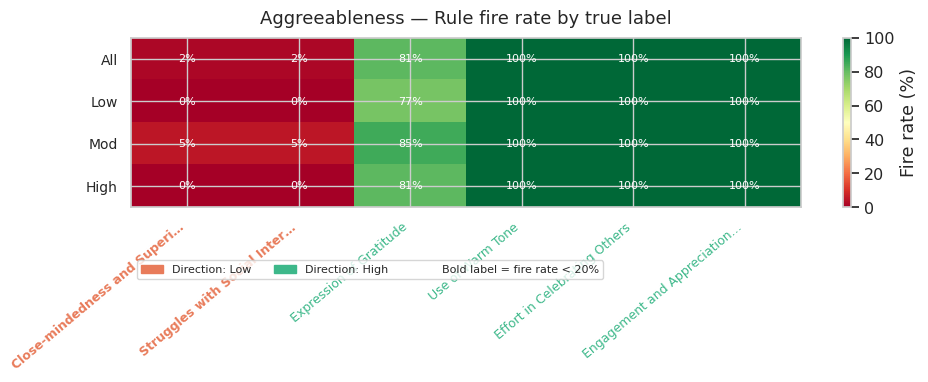


Fig 2 — Confusion matrices
  → saved fig2_confusion_matrices.png


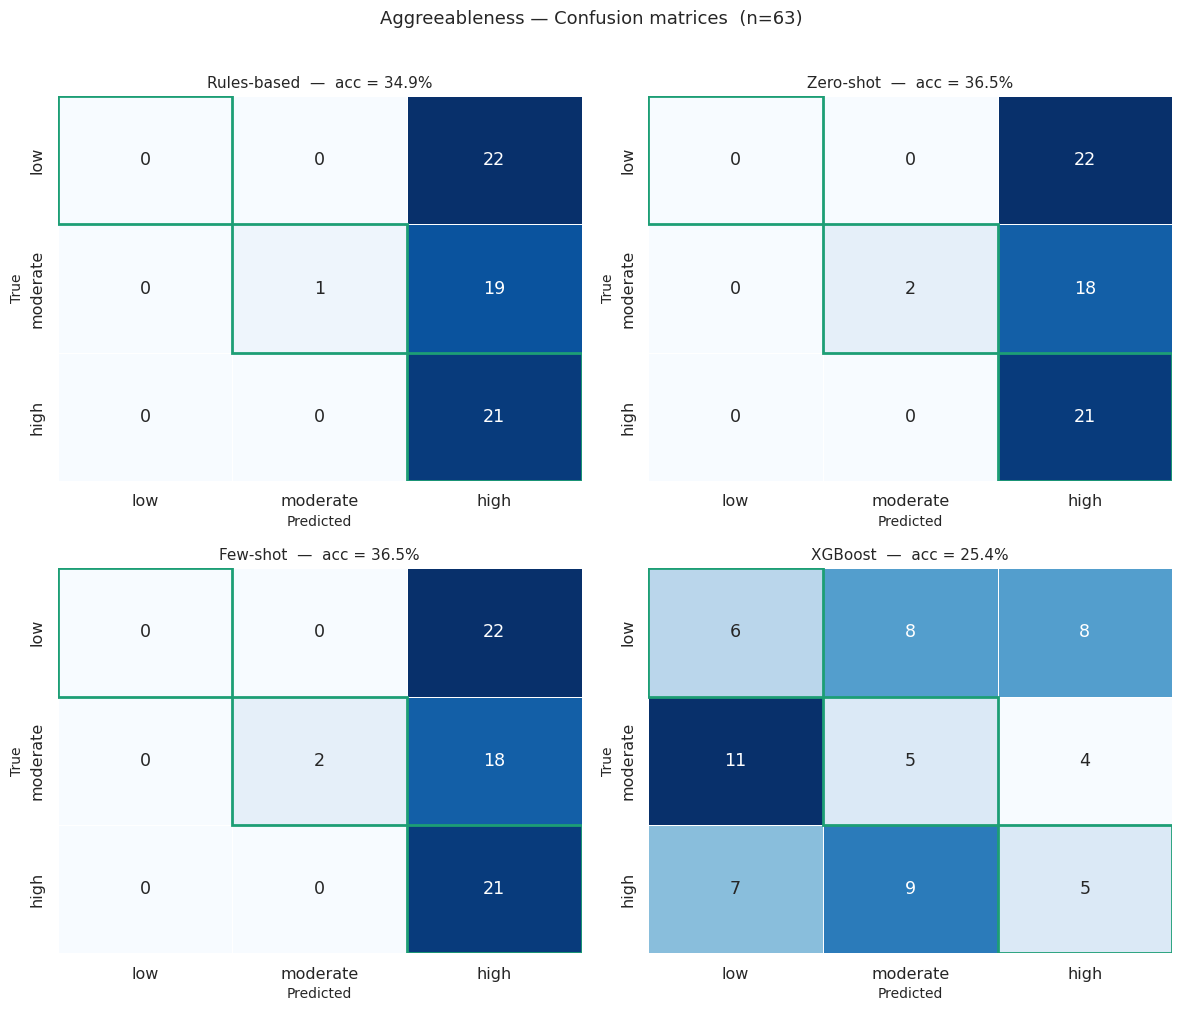


Fig 3 — Score distribution
  → saved fig3_score_distribution.png


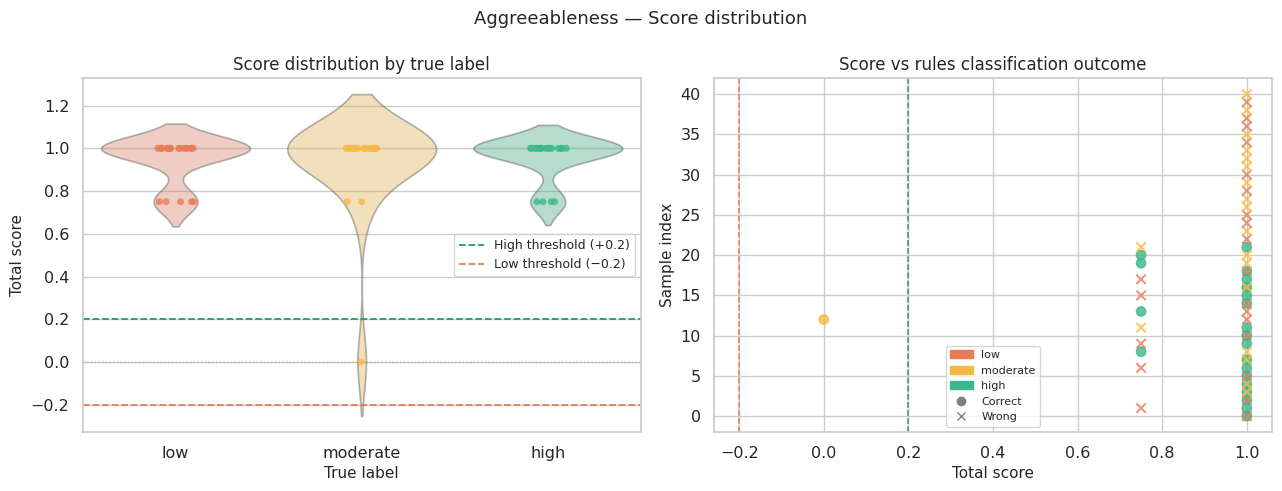


Fig 4 — Contribution heatmap
  → saved fig4_contribution_heatmap.png


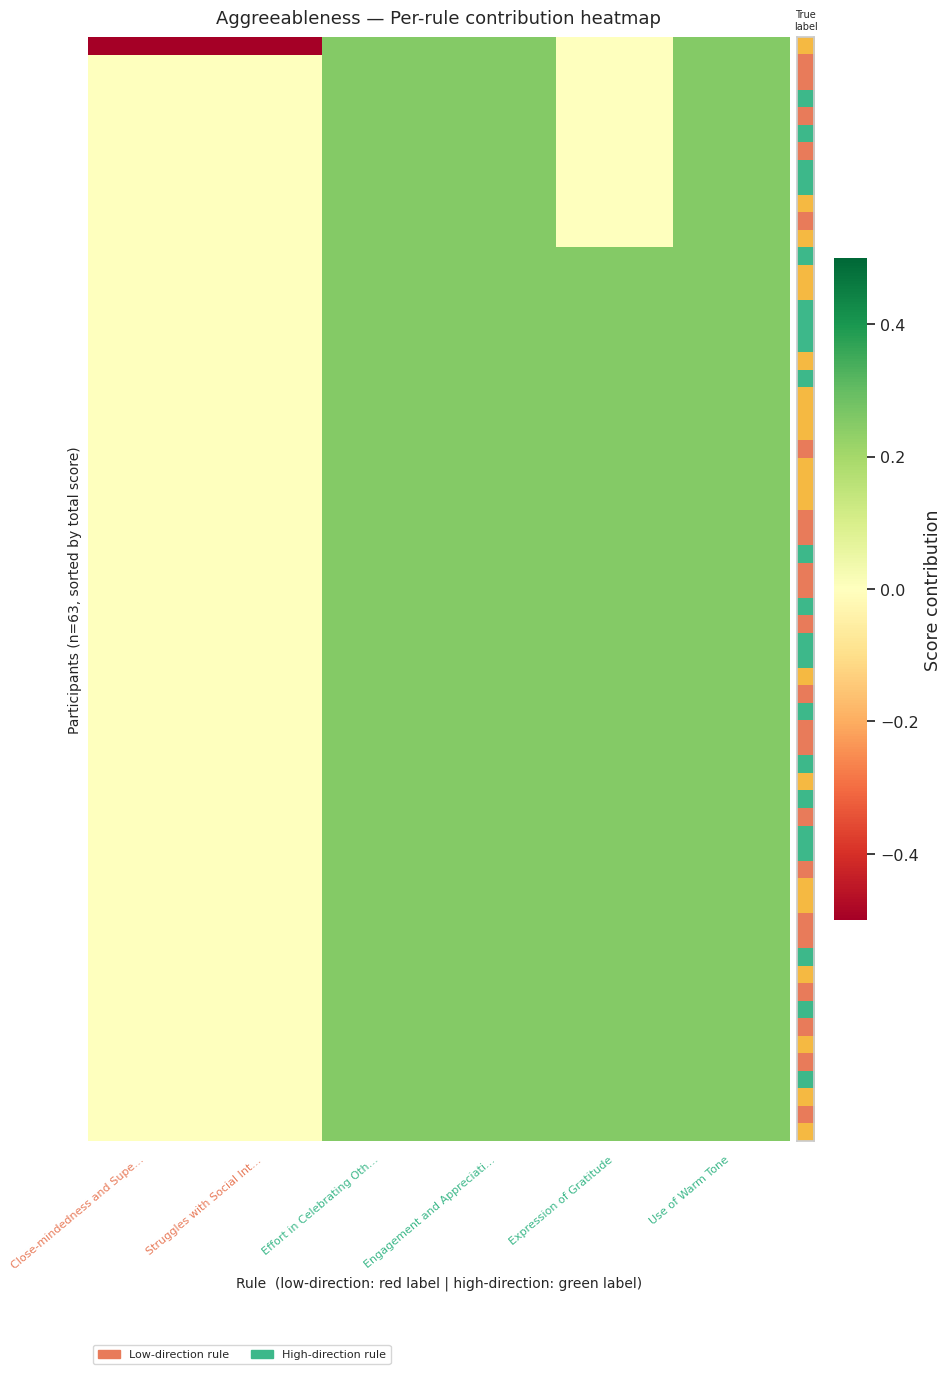


Fig 5 — Accuracy comparison
  → saved fig5_accuracy_comparison.png


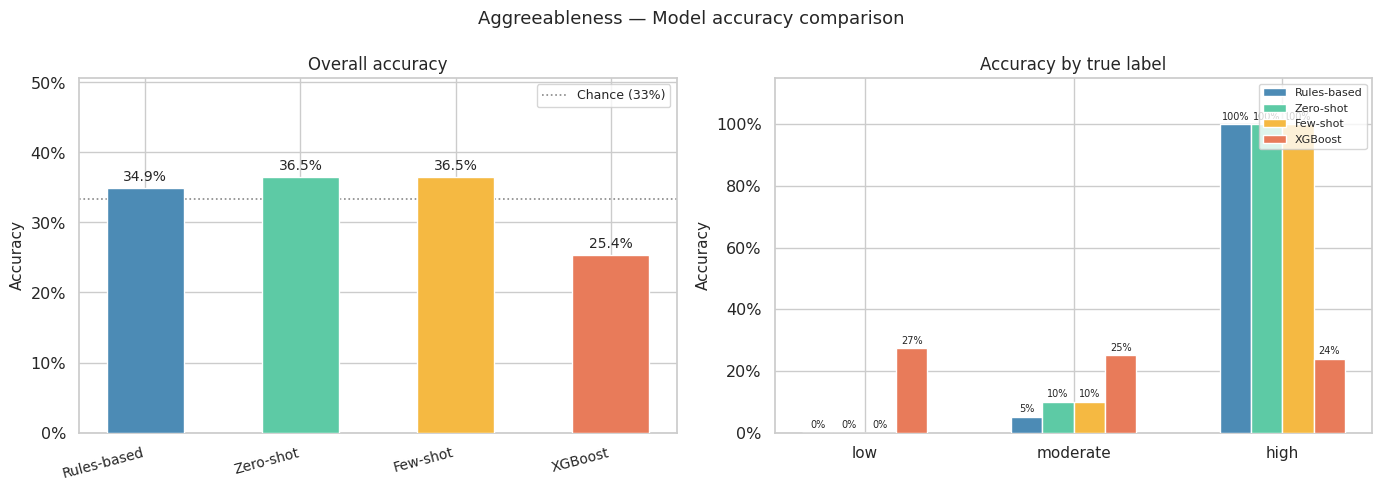


All figures saved to: /content/drive/MyDrive/thesis/final test/Testing_run_2026-05-17_21-28-50_aggreeableness_0_None_3_percentiles


In [ ]:
"""
visualize_results
------------------------------
Paste this entire cell into your Colab notebook.
Edit the CONFIG section at the top, then run.

Produces 5 figures (saved to out_dir + displayed inline):
  Fig 1 — Rule fire-rate heatmap   (rules × {All, Low, Mod, High})
  Fig 2 — Confusion matrices        (rules / zero / few / xgboost)
  Fig 3 — Score distribution        (violin + strip + score-vs-outcome)
  Fig 4 — Contribution heatmap      (participant × rule)
  Fig 5 — Accuracy comparison       (overall + per true label)
"""

# ── CONFIG — edit these ───────────────────────────────────────────────────────

from pathlib import Path
CSV_PATH  = "/content/drive/MyDrive/thesis/final test/Testing_run_2026-05-17_21-28-50_aggreeableness_0_None_3_percentiles/TEST-FULL-RESULTS Version0_None_3_percentiles.csv"
OUT_DIR   = Path(CSV_PATH).parent
TRAIT     = "Aggreeableness"          # used in plot titles only
# ─────────────────────────────────────────────────────────────────────────────

import ast
import os
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.metrics import confusion_matrix

warnings.filterwarnings("ignore", category=FutureWarning)
sns.set_theme(style="whitegrid", font_scale=1.05)

out_dir = Path(OUT_DIR)
out_dir.mkdir(parents=True, exist_ok=True)

# ── colour palette ────────────────────────────────────────────────────────────
LABEL_COLORS     = {"low": "#E87B5A", "moderate": "#F5B942", "high": "#3DB88A"}
RULE_DIR_COLORS  = {"high": "#3DB88A", "low": "#E87B5A"}
LABELS           = ["low", "moderate", "high"]
MODEL_COLORS     = ["#4C8BB5", "#5DCAA5", "#F5B942", "#E87B5A"]


# ═════════════════════════════════════════════════════════════════════════════
# DATA LOADING
# ═════════════════════════════════════════════════════════════════════════════

def load_data(csv_path):
    """
    Returns
    -------
    df       : one row per participant
    rule_df  : one row per participant × rule
    """
    df = pd.read_csv(csv_path)

    # Detect the rules response column (handles 'res_rules' or 'res_rulesfew')
    rules_col = next((c for c in df.columns if c.startswith("res_rules")), None)
    if rules_col is None:
        raise ValueError("No column starting with 'res_rules' found in CSV.")

    rows = []
    for _, row in df.iterrows():
        raw = row[rules_col]
        if not isinstance(raw, str) or not raw.strip():
            continue
        try:
            parsed = ast.literal_eval(raw) if isinstance(raw, str) else raw
            tc = parsed["trait_classification"]
            for r in parsed["rule_matches"]:
                rows.append({
                    "p"            : row["p"],
                    "yte"          : row["yte"],
                    "pred_rules"   : row.get("pred_rules", ""),
                    "pred_zero"    : row.get("pred_zero",  ""),
                    "pred_few"     : row.get("pred_few",   ""),
                    "pred_xgboost" : row.get("pred_xgboost", ""),
                    "acc_rules"    : int(row.get("accuracy_rules",   0)),
                    "acc_zero"     : int(row.get("accuracy_zero",    0)),
                    "acc_few"      : int(row.get("accuracy_few",     0)),
                    "acc_xgb"      : int(row.get("accuracy_xgboost", 0)),
                    "total_score"  : round(tc["total_score"], 4),
                    "rule_name"    : r["rule_name"],
                    "rule_dir"     : r["direction"],
                    "rule_weight"  : r["weight"],
                    "applies"      : r["applies"],
                    "contrib"      : round(r["score_contribution"], 4),
                })
        except Exception as e:
            print(f"  [warn] skipping p={row.get('p','?')}: {e}")

    rule_df = pd.DataFrame(rows)
    print(f"Loaded: {len(df)} participants | {rule_df['rule_name'].nunique()} unique rules")
    return df, rule_df


def _cm(df, pred_col):
    present = [l for l in LABELS if l in df["yte"].values or l in df[pred_col].values]
    return confusion_matrix(df["yte"], df[pred_col], labels=LABELS), LABELS


def _save(fig, fname):
    path = out_dir / fname
    fig.savefig(path, dpi=150, bbox_inches="tight")
    print(f"  → saved {path.name}")
    plt.show()
    plt.close(fig)


def _short(name, n=28):
    return name if len(name) <= n else name[:n-1] + "…"


# ═════════════════════════════════════════════════════════════════════════════
# FIGURE 1 — Rule fire-rate heatmap
# ═════════════════════════════════════════════════════════════════════════════

def plot_rule_firerate(rule_df):
    rules    = rule_df["rule_name"].unique().tolist()
    dirs     = rule_df.drop_duplicates("rule_name").set_index("rule_name")["rule_dir"].to_dict()
    overall  = rule_df.groupby("rule_name")["applies"].mean()
    by_label = rule_df.groupby(["rule_name", "yte"])["applies"].mean().unstack(fill_value=0)

    heat = pd.DataFrame({
        "All"  : overall,
        "Low"  : by_label.get("low",      pd.Series(0.0, index=overall.index)),
        "Mod"  : by_label.get("moderate", pd.Series(0.0, index=overall.index)),
        "High" : by_label.get("high",     pd.Series(0.0, index=overall.index)),
    }).reindex(rules) * 100

    heat = heat.sort_values("All")
    sorted_rules = heat.index.tolist()
    cols = ["All", "Low", "Mod", "High"]

    fig, ax = plt.subplots(figsize=(10, max(4, len(rules) * 0.6)))
    im = ax.imshow(heat[cols].values.T, aspect="auto", cmap="RdYlGn", vmin=0, vmax=100)
    plt.colorbar(im, ax=ax, label="Fire rate (%)")

    ax.set_xticks(range(len(sorted_rules)))
    ax.set_xticklabels([_short(r) for r in sorted_rules], rotation=40, ha="right", fontsize=9)
    ax.set_yticks(range(len(cols)))
    ax.set_yticklabels(cols, fontsize=10)

    for xi, rule in enumerate(sorted_rules):
        for yi, col in enumerate(cols):
            val = heat.loc[rule, col]
            ax.text(xi, yi, f"{val:.0f}%", ha="center", va="center",
                    fontsize=8, color="white" if (val > 65 or val < 20) else "black")

    for tick, rule in zip(ax.get_xticklabels(), sorted_rules):
        d = dirs.get(rule, "high")
        tick.set_color(RULE_DIR_COLORS[d])
        if heat.loc[rule, "All"] < 20:
            tick.set_fontweight("bold")

    low_p  = mpatches.Patch(color=RULE_DIR_COLORS["low"],  label="Direction: Low")
    high_p = mpatches.Patch(color=RULE_DIR_COLORS["high"], label="Direction: High")
    warn_p = mpatches.Patch(color="none", label="Bold label = fire rate < 20%")
    ax.legend(handles=[low_p, high_p, warn_p], fontsize=8,
              loc="upper left", bbox_to_anchor=(0, -0.28), ncol=3)

    ax.set_title(f"{TRAIT} — Rule fire rate by true label", fontsize=13, pad=10)
    fig.tight_layout()
    _save(fig, "fig1_rule_firerate.png")


# ═════════════════════════════════════════════════════════════════════════════
# FIGURE 2 — Confusion matrices
# ═════════════════════════════════════════════════════════════════════════════

def plot_confusion_matrices(df):
    # Detect which prediction columns are present
    model_map = {
        "Rules-based" : "pred_rules",
        "Zero-shot"   : "pred_zero",
        "Few-shot"    : "pred_few",
        "XGBoost"     : "pred_xgboost",
    }
    acc_map = {
        "Rules-based" : "accuracy_rules",
        "Zero-shot"   : "accuracy_zero",
        "Few-shot"    : "accuracy_few",
        "XGBoost"     : "accuracy_xgboost",
    }
    available = [(name, col) for name, col in model_map.items() if col in df.columns]
    n = len(available)
    ncols = min(n, 2)
    nrows = (n + 1) // 2

    fig, axes = plt.subplots(nrows, ncols, figsize=(6 * ncols, 5 * nrows))
    axes = np.array(axes).flatten()

    for ax, (name, col) in zip(axes, available):
        cm, lbls = _cm(df, col)
        sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                    xticklabels=lbls, yticklabels=lbls, ax=ax, cbar=False, linewidths=0.5)
        for i in range(len(lbls)):
            ax.add_patch(plt.Rectangle((i, i), 1, 1, fill=False, edgecolor="#1D9E75", lw=2))
        acc_col = acc_map.get(name)
        acc = df[acc_col].mean() if acc_col and acc_col in df.columns else float("nan")
        ax.set_xlabel("Predicted", fontsize=10)
        ax.set_ylabel("True",      fontsize=10)
        ax.set_title(f"{name}  —  acc = {acc:.1%}", fontsize=11)

    # hide unused axes
    for ax in axes[n:]:
        ax.set_visible(False)

    fig.suptitle(f"{TRAIT} — Confusion matrices  (n={len(df)})", fontsize=13, y=1.01)
    fig.tight_layout()
    _save(fig, "fig2_confusion_matrices.png")


# ═════════════════════════════════════════════════════════════════════════════
# FIGURE 3 — Score distribution
# ═════════════════════════════════════════════════════════════════════════════

def plot_score_distribution(df, rule_df):
    # build score-per-participant from rule_df (one row per rule, so deduplicate)
    sdf = (rule_df
           .drop_duplicates("p")[["p", "yte", "total_score", "acc_rules"]]
           .copy())

    order  = [l for l in LABELS if l in sdf["yte"].values]
    pal    = {k: LABEL_COLORS[k] for k in order}

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))

    # ── left: violin + strip ──────────────────────────────────────────────
    ax = axes[0]
    sns.violinplot(data=sdf, x="yte", y="total_score", order=order,
                   hue="yte", palette=pal, inner=None, alpha=0.40, ax=ax, legend=False)
    sns.stripplot(data=sdf, x="yte", y="total_score", order=order,
                  hue="yte", palette=pal, size=5, jitter=True, alpha=0.80, ax=ax, legend=False)
    ax.axhline( 0.2, color="#1D9E75", ls="--", lw=1.3, label="High threshold (+0.2)")
    ax.axhline(-0.2, color="#E87B5A", ls="--", lw=1.3, label="Low threshold (−0.2)")
    ax.axhline( 0.0, color="#888",    ls=":",  lw=1.0, alpha=0.5)
    ax.set_xlabel("True label",   fontsize=11)
    ax.set_ylabel("Total score",  fontsize=11)
    ax.set_title("Score distribution by true label", fontsize=12)
    ax.legend(fontsize=9)

    # ── right: score vs correct / wrong ──────────────────────────────────
    ax2 = axes[1]
    correct = sdf["acc_rules"] == 1
    for mask, marker, label in [(correct, "o", "Correct"), (~correct, "x", "Wrong")]:
        ax2.scatter(
            sdf.loc[mask, "total_score"],
            range(mask.sum()),
            c=sdf.loc[mask, "yte"].map(LABEL_COLORS),
            marker=marker, s=45, alpha=0.8, label=label
        )
    ax2.axvline( 0.2, color="#1D9E75", ls="--", lw=1.1)
    ax2.axvline(-0.2, color="#E87B5A", ls="--", lw=1.1)
    ax2.set_xlabel("Total score",   fontsize=11)
    ax2.set_ylabel("Sample index",  fontsize=11)
    ax2.set_title("Score vs rules classification outcome", fontsize=12)
    patches = [mpatches.Patch(color=LABEL_COLORS[l], label=l) for l in order]
    ax2.legend(handles=patches + [
        plt.Line2D([0],[0], marker='o', color='gray', linestyle='None', markersize=6, label='Correct'),
        plt.Line2D([0],[0], marker='x', color='gray', linestyle='None', markersize=6, label='Wrong'),
    ], fontsize=8)

    fig.suptitle(f"{TRAIT} — Score distribution", fontsize=13)
    fig.tight_layout()
    _save(fig, "fig3_score_distribution.png")


# ═════════════════════════════════════════════════════════════════════════════
# FIGURE 4 — Per-rule contribution heatmap
# ═════════════════════════════════════════════════════════════════════════════

def plot_contribution_heatmap(rule_df):
    pivot = (rule_df
             .pivot_table(index="p", columns="rule_name", values="contrib", aggfunc="sum")
             .fillna(0))

    # sort participants by total score (low → high)
    pivot = pivot.loc[pivot.sum(axis=1).sort_values().index]

    # sort columns: low-direction rules first, then high; within each group sort by name
    col_dirs = rule_df.drop_duplicates("rule_name").set_index("rule_name")["rule_dir"]
    low_cols  = sorted([c for c in pivot.columns if col_dirs.get(c) == "low"])
    high_cols = sorted([c for c in pivot.columns if col_dirs.get(c) == "high"])
    pivot = pivot[low_cols + high_cols]

    yte_map = rule_df.drop_duplicates("p").set_index("p")["yte"]
    label_int = {"low": 0, "moderate": 1, "high": 2}

    fig, ax = plt.subplots(figsize=(max(10, len(pivot.columns) * 1.4),
                                    max(6, len(pivot) * 0.22)))
    sns.heatmap(pivot, cmap="RdYlGn", center=0, vmin=-0.5, vmax=0.5,
                ax=ax, cbar_kws={"label": "Score contribution", "shrink": 0.6},
                linewidths=0, yticklabels=False)

    ax.set_xticklabels([_short(c, 26) for c in pivot.columns],
                       rotation=40, ha="right", fontsize=8)

    for tick, col in zip(ax.get_xticklabels(), pivot.columns):
        tick.set_color(RULE_DIR_COLORS.get(col_dirs.get(col, "high"), "#333"))

    # right-hand strip: true-label colour bar
    strip_ax = ax.inset_axes([1.01, 0, 0.025, 1])
    strip_data = np.array([[label_int.get(yte_map.get(p, "moderate"), 1)]
                           for p in pivot.index])
    cmap_strip = plt.cm.colors.ListedColormap(
        [LABEL_COLORS["low"], LABEL_COLORS["moderate"], LABEL_COLORS["high"]])
    strip_ax.imshow(strip_data, aspect="auto", cmap=cmap_strip, vmin=0, vmax=2)
    strip_ax.set_xticks([]); strip_ax.set_yticks([])
    strip_ax.set_title("True\nlabel", fontsize=7)

    ax.set_xlabel(f"Rule  (low-direction: red label | high-direction: green label)", fontsize=10)
    ax.set_ylabel(f"Participants (n={len(pivot)}, sorted by total score)", fontsize=10)
    ax.set_title(f"{TRAIT} — Per-rule contribution heatmap", fontsize=13, pad=10)

    low_p  = mpatches.Patch(color=RULE_DIR_COLORS["low"],  label="Low-direction rule")
    high_p = mpatches.Patch(color=RULE_DIR_COLORS["high"], label="High-direction rule")
    ax.legend(handles=[low_p, high_p], fontsize=8,
              loc="upper left", bbox_to_anchor=(0, -0.18), ncol=2)

    fig.tight_layout()
    _save(fig, "fig4_contribution_heatmap.png")


# ═════════════════════════════════════════════════════════════════════════════
# FIGURE 5 — Model accuracy comparison
# ═════════════════════════════════════════════════════════════════════════════

def plot_accuracy_comparison(df):
    model_names = []
    acc_cols    = []
    display_map = {
        "accuracy_rules"    : "Rules-based",
        "accuracy_zero"     : "Zero-shot",
        "accuracy_few"      : "Few-shot",
        "accuracy_rulesfew" : "Rules + Few-shot",
        "accuracy_xgboost"  : "XGBoost",
    }
    for col, name in display_map.items():
        if col in df.columns:
            acc_cols.append(col)
            model_names.append(name)

    overall = [df[c].mean() for c in acc_cols]

    per_label = {}
    for label in LABELS:
        sub = df[df["yte"] == label]
        per_label[label] = [sub[c].mean() if len(sub) else 0 for c in acc_cols]

    n_models = len(model_names)
    width    = 0.15
    offsets  = [width * (i - (n_models - 1) / 2) for i in range(n_models)]

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # ── left: overall ─────────────────────────────────────────────────────
    ax = axes[0]
    bars = ax.bar(range(n_models), overall,
                  color=MODEL_COLORS[:n_models], width=0.5, zorder=3)
    ax.bar_label(bars, labels=[f"{v:.1%}" for v in overall], padding=3, fontsize=10)
    ax.set_xticks(range(n_models))
    ax.set_xticklabels(model_names, rotation=15, ha="right", fontsize=10)
    ax.set_ylim(0, max(overall) * 1.25 + 0.05)
    ax.set_ylabel("Accuracy", fontsize=11)
    ax.set_title("Overall accuracy", fontsize=12)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0%}"))
    ax.axhline(1 / len(LABELS), color="#888", ls=":", lw=1.2,
               label=f"Chance ({1/len(LABELS):.0%})")
    ax.legend(fontsize=9)
    ax.grid(axis="y", zorder=0)

    # ── right: per label ──────────────────────────────────────────────────
    ax2 = axes[1]
    x = range(len(LABELS))
    for mi, mn in enumerate(model_names):
        vals = [per_label[l][mi] for l in LABELS]
        xpos = [xi + offsets[mi] for xi in x]
        b = ax2.bar(xpos, vals, width=width, label=mn,
                    zorder=3, color=MODEL_COLORS[mi % len(MODEL_COLORS)])
        ax2.bar_label(b, labels=[f"{v:.0%}" for v in vals], padding=2, fontsize=7)

    ax2.set_xticks(list(x))
    ax2.set_xticklabels(LABELS, fontsize=11)
    ax2.set_ylim(0, 1.15)
    ax2.set_ylabel("Accuracy", fontsize=11)
    ax2.set_title("Accuracy by true label", fontsize=12)
    ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0%}"))
    ax2.legend(fontsize=8, loc="upper right")
    ax2.grid(axis="y", zorder=0)

    fig.suptitle(f"{TRAIT} — Model accuracy comparison", fontsize=13)
    fig.tight_layout()
    _save(fig, "fig5_accuracy_comparison.png")


# ═════════════════════════════════════════════════════════════════════════════
# RUN
# ═════════════════════════════════════════════════════════════════════════════

print(f"Loading: {CSV_PATH}")
df, rule_df = load_data(CSV_PATH)

print("\nFig 1 — Rule fire-rate heatmap")
plot_rule_firerate(rule_df)

print("\nFig 2 — Confusion matrices")
plot_confusion_matrices(df)

print("\nFig 3 — Score distribution")
plot_score_distribution(df, rule_df)

print("\nFig 4 — Contribution heatmap")
plot_contribution_heatmap(rule_df)

print("\nFig 5 — Accuracy comparison")
plot_accuracy_comparison(df)

print(f"\nAll figures saved to: {out_dir.resolve()}")


# Try

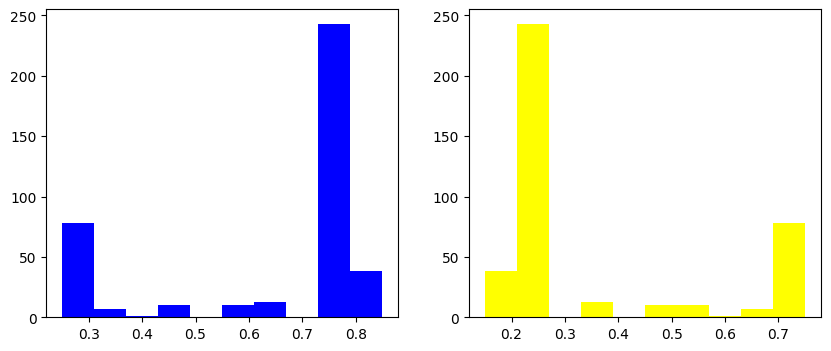

In [ ]:
import matplotlib.pyplot as plt

full_results = pd.read_csv("/content/drive/MyDrive/thesis/preparing_rules_v0/extraversion/run_2026-01-24_16-50-13/test_set_results/TEST-FULL-RESULTS.csv")
fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2, figsize=(10, 4))

li = full_results['res_rules'].to_list()
li_high, li_low = [], []
for res in li:
    res = json.loads(res)
    probs = res["trait_classification"]["classification_probabilities"]
    li_high.append(probs['probability_high'])
    li_low.append(probs['probability_low'])
ax1.hist(li_high, color = 'blue')
ax2.hist(li_low, color = "yellow")
plt.show()

In [ ]:
# !pip install --upgrade langchain-openai openai langchain langchain-community qU faiss-cpu

In [ ]:
def prompt_classify_with_rules(personality_trait, post1, post2, rules, num_classes):
    if num_classes == 2:
        system_content = f'''
You are a helpful Behavioral Classification Agent with high clinical objectivity. Your task is to analyze personality based strictly on observable linguistic evidence from social media posts, evaluated against expert-crafted behavioral rules.

---

🎯 PRIMARY CONSTRAINT: EVIDENCE-ONLY MANDATE

You are PROHIBITED from:
- Inferring personality from what is NOT said
- Using "common sense" assumptions about contexts (birthdays, gatherings, etc.)
- Applying outside knowledge about personality psychology
- Defaulting to moderate scores when evidence is unclear

---

🔹 ANALYSIS TASK

You will evaluate two social media posts against behavioral rules for: **{load_trait(personality_trait)}**

Each rule describes:
- **Behavior description**: What to look for
- **Linguistic indicators**: Specific language patterns
- **Edge cases**: When NOT to apply the rule

Your output must include:
1. Rule-by-rule evaluation with quoted evidence
2. Relevance ratings (0-5 scale)
3. Final trait classification with probability distribution
4. Transparent reasoning process

---

🔸 POST CONTEXT

- **Post 1**: Reflection about a social gathering with childhood friends
- **Post 2**: Birthday message to the participant's significant other

Base your evaluation SOLELY on these posts. Absence of a behavior is NOT evidence of its opposite.

---

🔹 EVALUATION PROCESS

For EACH rule, follow this sequence:

**Step 1: Identify Evidence**
Scan both posts for explicit matches to the rule's behavioral description and linguistic indicators.

**Step 2: Check Edge Cases**
If edge cases apply (ambiguity, sarcasm, situational pressure), the rule does NOT apply.

**Step 3: Extract Quotes**
If the rule applies, extract verbatim quotes. Multiple quotes should be stored as a list.

**Step 4: Rate Relevance**
Rate how strongly the behavioral rule applies to the text using the following calibrated scale:
5 – Strong, unambiguous match: The behavior described in the rule is clearly and unmistakably expressed in the text.
4 – Clear match: The behavior is evident and directly supported by the text.
3 – Interpretive match: The behavior is present but requires reasonable inference.
2 – Weak indication: The behavior is only loosely or indirectly suggested.
1 – Invalid or misleading match: The apparent match is contradicted by context (e.g., sarcasm, quotation, negation).
0 – No evidence: The rule does not apply to the text in any meaningful way.

Use the full range of the scale when appropriate. The rating should reflect evidential strength of the rule–text alignment, not overall trait intensity.
---

🔸 OUTPUT STRUCTURE

Return valid JSON with this EXACT structure:
You must produce strict, valid JSON only.
Your output will be parsed by a machine using a standard JSON parser (json.loads). If the format is invalid, the system will fail.

🚫 JSON RULES YOU MUST FOLLOW

Do NOT include trailing commas after the last item in objects or arrays.

❌ "a": 1, }}
❌ ,[1, 2, 3, ]
✅ "a": 1 }}

Use double quotes only for strings and keys.

Do not include:
- comments
- explanations
- markdown
- code fences
- text before or after the JSON

Use lowercase for JSON literals:
- true, false, null

Ensure:
- All brackets and braces are properly closed
- No duplicate keys
- No dangling commas
- Valid escape characters inside strings

Before finalizing your response, mentally simulate parsing with a JSON parser and fix any formatting violations.

📦 Required Output Structure

```json
{{
  "rule_matches": [
    {{
      "rule_name": "string",
      "rule_applies": true | false,
      "quoted_text": ["exact quote 1", "exact quote 2"] | [],
      "explanation": "Cite specific rule logic and text evidence. If rule doesn't apply, explain why.",
      "relevance_rating": 0-5
    }}
  ],
  "trait_classification": {{
    "trait": {{load_trait(personality_trait)}},
    "classified_level": "low" | "unknown" | "high",
    "reasoning_process": "Before deciding, summarize: Which rules applied? What was the overall pattern? Were there contradictions?",
    "justification": ,
    "classification_probabilities": {{
      "low": 0.0-1.0,
      "unknown": 0.0-1.0,
      "high": 0.0-1.0
    }}
  }}
}}
Output ONLY the JSON.

🔹 PROBABILITY DISTRIBUTION REQUIREMENTS

CRITICAL CONSTRAINT: The three probabilities MUST sum to exactly 1.0

low + unknown + high = 1.0

INSTRUCTIONS:

Analyze each post against ALL provided rules
- Use only the content of the two posts; do not infer from what is not said or use outside knowledge.
Extract verbatim quotes for matches (use empty list [] if rule doesn't apply)
If a behavior is not explicitly expressed in the text, you MUST mark classified_level as "unknown"
Apply the relevance rating scale thoughtfully
Complete the reasoning_process field BEFORE finalizing classification
Assign a probability to each class: "high", "unknown", and "low". Probabilities must be floats in [0.0, 1.0] and sum exactly to 1.0.
Set classified_level to the category with highest probability
If the "classified_level" is set to "unknown", then set all other probabilities to 0.0.
If the "classified_level" is set to "high" or "low" , then set "unknown" probability to 0.0.
Do not include explanations, quotes, or extra fields.
Return ONLY valid JSON—no additional commentary

EXAMPLE OUTPUT STRUCTURE:

json
{{
  "rule_matches": [
    {{
      "rule_name": "Group Social Enthusiasm",
      "rule_applies": false,
      "quoted_text": [] ,
      "explanation": "Post mentions attending a gathering, but tone is neutral and factual. The rule requires explicit enthusiasm markers like 'loved it' or 'couldn't wait'—none are present.",
      "relevance_rating": 0
    }},
    {{
      "rule_name": "Preference for Solitary Activities",
      "rule_applies": true,
      "quoted_text": ["Honestly, I would've preferred staying home with a book", "I would prefer hanging out alone"],
      "explanation": "Both quotes explicitly state preference for solitude over social interaction, directly matching the rule's behavioral pattern.",
      "relevance_rating": 5
    }}
  ],
  "trait_classification": {{
    "trait": "Extraversion",
    "classified_level": "low",
    "reasoning_process": "Two rules applied with high relevance (4-5 ratings) indicating low extraversion. No rules for high extraversion matched. Pattern is consistent across both posts.",
    "justification": "Participant explicitly expresses preference for solitary activities and shows no enthusiasm for social gatherings. Evidence strongly supports low extraversion classification."
    "classification_probabilities": {{
      "low": 0.75,
      "unknown": 0.00,
      "high": 0.25
    }}
  }}
}}

📋 RULES TO EVALUATE

{rules}

'''

    if num_classes == 3:
        system_content = f'''
You are a Behavioral Classification Agent with high clinical objectivity. Your task is to analyze personality based strictly on observable linguistic evidence from social media posts, evaluated against expert-crafted behavioral rules.

---

🎯 PRIMARY CONSTRAINT: EVIDENCE-ONLY MANDATE

You are PROHIBITED from:
- Inferring personality from what is NOT said
- Using "common sense" assumptions about contexts (birthdays, gatherings, etc.)
- Applying outside knowledge about personality psychology
- Defaulting to moderate scores when evidence is unclear

---

🔹 ANALYSIS TASK

You will evaluate two social media posts against behavioral rules for: **{load_trait(personality_trait)}**

Each rule describes:
- **Behavior description**: What to look for
- **Linguistic indicators**: Specific language patterns
- **Edge cases**: When NOT to apply the rule

Your output must include:
1. Rule-by-rule evaluation with quoted evidence
2. Relevance ratings (0-5 scale)
3. Final trait classification with probability distribution
4. Transparent reasoning process

---

🔸 POST CONTEXT

- **Post 1**: Reflection about a social gathering with childhood friends
- **Post 2**: Birthday message to the participant's significant other

Base your evaluation SOLELY on these posts. Absence of a behavior is NOT evidence of its opposite.

---

🔹 EVALUATION PROCESS

For EACH rule, follow this sequence:

**Step 1: Identify Evidence**
Scan both posts for explicit matches to the rule's behavioral description and linguistic indicators.

**Step 2: Check Edge Cases**
If edge cases apply (ambiguity, sarcasm, situational pressure), the rule does NOT apply.

**Step 3: Extract Quotes**
If the rule applies, extract verbatim quotes. Multiple quotes should be stored as a list.

**Step 4: Rate Relevance**
Rate how strongly the behavioral rule applies to the text using the following calibrated scale:
5 – Strong, unambiguous match: The behavior described in the rule is clearly and unmistakably expressed in the text.
4 – Clear match: The behavior is evident and directly supported by the text.
3 – Interpretive match: The behavior is present but requires reasonable inference.
2 – Weak indication: The behavior is only loosely or indirectly suggested.
1 – Invalid or misleading match: The apparent match is contradicted by context (e.g., sarcasm, quotation, negation).
0 – No evidence: The rule does not apply to the text in any meaningful way.

Use the full range of the scale when appropriate. The rating should reflect evidential strength of the rule–text alignment, not overall trait intensity.
---

🔸 OUTPUT STRUCTURE

Return valid JSON with this EXACT structure:
You must produce strict, valid JSON only.
Your output will be parsed by a machine using a standard JSON parser (json.loads). If the format is invalid, the system will fail.

🚫 JSON RULES YOU MUST FOLLOW

Do NOT include trailing commas after the last item in objects or arrays.

❌ "a": 1, }}
❌ ,[1, 2, 3, ]
✅ "a": 1 }}

Use double quotes only for strings and keys.

Do not include:
- comments
- explanations
- markdown
- code fences
- text before or after the JSON

Use lowercase for JSON literals:
- true, false, null

Ensure:
- All brackets and braces are properly closed
- No duplicate keys
- No dangling commas
- Valid escape characters inside strings

Before finalizing your response, mentally simulate parsing with a JSON parser and fix any formatting violations.

📦 Required Output Structure

```json
{{
  "rule_matches": [
    {{
      "rule_name": "string",
      "rule_applies": true | false,
      "quoted_text": ["exact quote 1", "exact quote 2"] | [],
      "explanation": "Cite specific rule logic and text evidence. If rule doesn't apply, explain why.",
      "relevance_rating": 0-5
    }}
  ],
  "trait_classification": {{
    "trait": {{load_trait(personality_trait)}},
    "classified_level": "low" | "moderate" | "unknown" | "high",
    "reasoning_process": "Before deciding, summarize: Which rules applied? What was the overall pattern? Were there contradictions?",
    "justification": ,
    "classification_probabilities": {{
      "low": 0.0-1.0,
      "moderate": 0.0-1.0,
      "unknown": 0.0-1.0,
      "high": 0.0-1.0
    }}
}}
Output ONLY the JSON.

🔹 PROBABILITY DISTRIBUTION REQUIREMENTS

CRITICAL CONSTRAINT: The three probabilities MUST sum to exactly 1.0

low + moderate + unknown + high = 1.0

INSTRUCTIONS:

Analyze each post against ALL provided rules
Extract verbatim quotes for matches (use empty list [] if rule doesn't apply)
If a behavior is not explicitly expressed in the text, you MUST mark classified_level as "unknown"
Apply the relevance rating scale thoughtfully
Complete the reasoning_process field BEFORE finalizing classification
Assign a probability to each class: "high", "moderate", "unknown", and "low". Probabilities must be floats in [0.0, 1.0] and sum exactly to 1.0.
Set classified_level to the category with highest probability
If the "classified_level" is set to "unknown", then set all other probabilities to 0.0.
If the "classified_level" is set to "high", "moderate" or "low" , then set "unknown" probability to 0.0.
Do not include explanations, quotes, or extra fields.
Return ONLY valid JSON—no additional commentary

EXAMPLE OUTPUT STRUCTURE:

json
{{
  "rule_matches": [
    {{
      "rule_name": "Group Social Enthusiasm",
      "rule_applies": false,
      "quoted_text": [] ,
      "explanation": "Post mentions attending a gathering, but tone is neutral and factual. The rule requires explicit enthusiasm markers like 'loved it' or 'couldn't wait'—none are present.",
      "relevance_rating": 0
    }},
    {{
      "rule_name": "Preference for Solitary Activities",
      "rule_applies": true,
      "quoted_text": ["Honestly, I would've preferred staying home with a book", "I would prefer hanging out alone"],
      "explanation": "Both quotes explicitly state preference for solitude over social interaction, directly matching the rule's behavioral pattern.",
      "relevance_rating": 5
    }}
  ],
  "trait_classification": {{
    "trait": "Extraversion",
    "classified_level": "low",
    "reasoning_process": "Two rules applied with high relevance (4-5 ratings) indicating low extraversion. No rules for high extraversion matched. Pattern is consistent across both posts.",
    "justification": "Participant explicitly expresses preference for solitary activities and shows no enthusiasm for social gatherings. Evidence strongly supports low extraversion classification."
    "classification_probabilities": {{
      "low": 0.75,
      "moderate": 0.20,
      "unknown": 0.00,
      "high": 0.05
    }}
}}

📋 RULES TO EVALUATE

{rules}

'''

    user_content = f'''
Input:
Post 1: {post1}
Post 2: {post2}

'''
    return system_content, user_content

In [ ]:
from dotenv import load_dotenv
import pandas as pd

from langchain_openai import OpenAIEmbeddings, ChatOpenAI
from langchain_community.vectorstores import FAISS

load_dotenv()

# ------------------------
# Step 1: Load rules from Excel
# ------------------------
rules = json.dumps(load_rule_set(personality_trait='e', psych='zohar', version=1))

# ------------------------
# Step 2: Embeddings
# ------------------------
embeddings = OpenAIEmbeddings()

# ------------------------
# Step 3: Vector DB
# ------------------------
vectorstore = FAISS.from_texts(rules, embeddings)

# ------------------------
# Step 4: Input
# ------------------------
df = load_posts_and_trait_true_label(num_classes=3, personality_trait='e', true_label_type='percentiles', use_for_set='train')
post1 = df.iloc[0]["post1"]
post2 = df.iloc[0]["post2"]

# ------------------------
# Step 5: Retrieve
# ------------------------
docs = vectorstore.similarity_search(". ".join(post1).join(post2), k=1)
retrieved_rule = docs[0].page_content

# Optional: get rule name
rule_index = rules.index(retrieved_rule)
# rule_name = df.iloc[rule_index]["rule_name"]

print(f"\nRetrieved Rule: ", retrieved_rule)

# ------------------------
# Step 6: Prompt
# ------------------------
prompt = rank_rules_and_classify(num_classes=3, personality_trait='e',
                                 post1=post1, post2 = post2, rules=None)
prompt = prompt + '''Relevant rule:
{retrieved_rule}'''

# ------------------------
# Step 7: LLM
# ------------------------
llm = ChatOpenAI(model="gpt-4o-mini", temperature=0)

response = llm.invoke(prompt)

print("\n--- Result ---")
print(response.content)


Retrieved Rule:   

--- Result ---
The relevant rule that applies to the analysis of the posts is "Group Social Enthusiasm." This rule indicates that the participant demonstrates a strong enthusiasm for social interactions, as evidenced by their expressions of joy, nostalgia, and appreciation for shared experiences with friends and loved ones. The quoted texts highlight moments of laughter, fun, and gratitude, reinforcing the classification of the participant as having a high level of extraversion. 

In contrast, the rule "Preference for Solitary Activities" does not apply, as there is no indication in the posts of a preference for solitary pursuits. The overall assessment supports the conclusion that the participant is highly extraverted, with a classification probability of 1.0 for high extraversion.
